# [13.2] Denoising-Time Causal Patching

> **Notebooks: [exercises](13.2_Denoising-Time_Causal_Patching_exercises.ipynb) | [solutions](13.2_Denoising-Time_Causal_Patching_solutions.ipynb)**

By the end of this notebook, you will have shown that concept information in a diffusion trajectory can be causally localized in **denoising time, network depth, channels, and image space**: a donor patch recovers the target concept, while matched wrong-time, wrong-region, random-latent, shuffled-label, and unpatched controls do not.

## Core Question

**When does a diffusion model decide what will appear in a particular part of the image?**

The signature result is not an image grid. It is a falsifiable intervention curve: the same donor information should work at a specific time and place, and fail when either coordinate is wrong.


In [1]:
import json
import math
import sys
import time
from dataclasses import asdict
from pathlib import Path
from typing import Any, Iterable, Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch as t
from IPython.display import display
from torch import Tensor, nn
from torch.nn import functional as F

GT_TIER = "GT-0"
REAL_EXTENSION_GT_TIER = "GT-3"
EXERCISE_ID = "13_2_denoising_time_causal_patching"
DIFFICULTY = 5
IMPORTANCE = 5
EXPECTED_RUNTIME = "120-180 minutes; the full real sweep runs on CUDA"
REQUIRES_GPU = True

chapter = "chapter13_image_generation_interpretability"
section = "part2_denoising_time_causal_patching"
root_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / chapter).exists())
exercises_dir = root_dir / chapter / "exercises"
section_dir = exercises_dir / section
assets_dir = root_dir / chapter / "instructions" / "assets"
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from chapter13_image_generation_interpretability.exercises.part2_denoising_time_causal_patching import solutions as reference
from chapter13_image_generation_interpretability.exercises.part2_denoising_time_causal_patching import tests

DiffusionSchedule = reference.DiffusionSchedule
ActivationCache = reference.ActivationCache
ActivationPatch = reference.ActivationPatch
RegionalCausalMetric = reference.RegionalCausalMetric
LatentTransferMetric = reference.LatentTransferMetric
SD15Trajectory = reference.SD15Trajectory
SD15PatchControlReport = reference.SD15PatchControlReport
PATCH_LAYERS = reference.PATCH_LAYERS
N_DIFFUSION_STEPS = reference.N_DIFFUSION_STEPS
IMAGE_SIZE = reference.IMAGE_SIZE
N_SHAPES = reference.N_SHAPES
N_COLORS = reference.N_COLORS
N_ROWS = reference.N_ROWS
N_COLUMNS = reference.N_COLUMNS
COLOR_VALUES = reference.COLOR_VALUES
REAL_SD15_NEGATIVE_PROMPT = reference.REAL_SD15_NEGATIVE_PROMPT
plt.style.use("seaborn-v0_8-whitegrid")


## Learning Objectives

You will be able to:

- derive and test the forward diffusion equation at an exact clean endpoint;
- cache activations by denoising timestep and layer;
- replace only selected channels and spatial locations without mutating the cache;
- implement a deterministic DDIM-style denoising loop with one causal intervention;
- calibrate target recovery against clean and corrupt endpoints;
- sweep layer and denoising time on a trained model organism with known ground truth;
- write the explicit Stable Diffusion 1.5 denoising loop instead of treating the pipeline as a black box;
- compare a real donor-latent intervention against wrong-time, wrong-region, random-latent, and unpatched controls;
- reject an attractive image when its metric or controls do not support the causal claim.

## Cold Open: The Same Patch, Four Different Claims

Imagine inserting a red-square donor latent into a blue-square trajectory.

1. At every timestep: this may simply overwrite the generation.
2. In the whole latent: this may replace the entire image.
3. At one timestep and one region: this can localize a causal state.
4. At one timestep and one region, but with no controls: this can still be a coincidence.

Before coding, predict whether early, middle, or late denoising calls should carry the most portable color information. You will have to update that prediction from the evidence.

## Part 1: Exact Toy Ground Truth

The toy world contains every combination of two shapes, three colors, two rows, and two columns. Its denoiser has an explicit concept bottleneck. This is not evidence about SD1.5; it is an oracle for whether your patching method can recover a circuit that is actually there.


### Exercise 1: Derive the Forward Noising Step

> Difficulty: 🔴🔴⚪⚪⚪ | Importance: 🔵🔵🔵🔵⚪ | 15 minutes

Implement a schedule with an exact clean endpoint and the closed-form sample from $q(x_t\mid x_0)$. Broadcasting must work for a different timestep per image.


In [2]:
def make_diffusion_schedule(
    n_steps: int = N_DIFFUSION_STEPS,
    beta_start: float = 0.03,
    beta_end: float = 0.22,
    *,
    device: t.device | str = "cpu",
) -> DiffusionSchedule:
    """Return a schedule with an exact clean endpoint at timestep zero."""
    if n_steps < 2:
        raise ValueError("n_steps must be at least two so early/late controls exist.")
    if not 0.0 < beta_start < beta_end < 1.0:
        raise ValueError("Require 0 < beta_start < beta_end < 1.")
    betas = t.cat(
        [
            t.zeros(1, device=device),
            t.linspace(beta_start, beta_end, n_steps, device=device),
        ]
    )
    alphas = 1.0 - betas
    alpha_bars = t.cumprod(alphas, dim=0)
    return DiffusionSchedule(betas=betas, alphas=alphas, alpha_bars=alpha_bars)


def q_sample(
    x_start: Tensor,
    timesteps: Tensor,
    noise: Tensor,
    schedule: DiffusionSchedule,
) -> Tensor:
    """Sample q(x_t | x_0) with one independently testable broadcast operation."""
    if x_start.shape != noise.shape:
        raise ValueError("x_start and noise must have identical shapes.")
    if timesteps.shape != (x_start.shape[0],):
        raise ValueError("timesteps must have shape [batch].")
    if timesteps.min() < 0 or timesteps.max() >= len(schedule.alpha_bars):
        raise ValueError("A timestep lies outside the schedule.")
    alpha_bar = schedule.alpha_bars[timesteps].view(-1, 1, 1, 1)
    return alpha_bar.sqrt() * x_start + (1.0 - alpha_bar).sqrt() * noise


tests.test_diffusion_schedule_has_exact_endpoint_and_valid_noise(make_diffusion_schedule, q_sample)


All tests in `test_diffusion_schedule_has_exact_endpoint_and_valid_noise` passed!


<details>
        <summary>Expected output</summary>

        ```text
        All tests in `test_diffusion_schedule_has_exact_endpoint_and_valid_noise` passed!
        ```
        </details>

        <details>
        <summary>Help - getting started</summary>

        Prepend a zero beta, take cumulative products of $1-\beta_t$, then reshape the selected $\bar\alpha_t$ values to `[batch, 1, 1, 1]`.
        </details>

        <details>
        <summary>Common bugs</summary>

        - forgetting the explicit `t=0` entry
- broadcasting one timestep across the batch
- mixing alpha with cumulative alpha-bar
        </details>

        <details>
        <summary>Interpretation</summary>

        At `t=0`, noising must be exactly the identity. If this anchor drifts, every later recovery score is miscalibrated.
        </details>

        <details>
        <summary>Solution</summary>

        ```python
        def make_diffusion_schedule(
    n_steps: int = N_DIFFUSION_STEPS,
    beta_start: float = 0.03,
    beta_end: float = 0.22,
    *,
    device: t.device | str = "cpu",
) -> DiffusionSchedule:
    """Return a schedule with an exact clean endpoint at timestep zero."""
    if n_steps < 2:
        raise ValueError("n_steps must be at least two so early/late controls exist.")
    if not 0.0 < beta_start < beta_end < 1.0:
        raise ValueError("Require 0 < beta_start < beta_end < 1.")
    betas = t.cat(
        [
            t.zeros(1, device=device),
            t.linspace(beta_start, beta_end, n_steps, device=device),
        ]
    )
    alphas = 1.0 - betas
    alpha_bars = t.cumprod(alphas, dim=0)
    return DiffusionSchedule(betas=betas, alphas=alphas, alpha_bars=alpha_bars)


def q_sample(
    x_start: Tensor,
    timesteps: Tensor,
    noise: Tensor,
    schedule: DiffusionSchedule,
) -> Tensor:
    """Sample q(x_t | x_0) with one independently testable broadcast operation."""
    if x_start.shape != noise.shape:
        raise ValueError("x_start and noise must have identical shapes.")
    if timesteps.shape != (x_start.shape[0],):
        raise ValueError("timesteps must have shape [batch].")
    if timesteps.min() < 0 or timesteps.max() >= len(schedule.alpha_bars):
        raise ValueError("A timestep lies outside the schedule.")
    alpha_bar = schedule.alpha_bars[timesteps].view(-1, 1, 1, 1)
    return alpha_bar.sqrt() * x_start + (1.0 - alpha_bar).sqrt() * noise

        ```
        </details>


### Exercise 2: Build the Object World and Its Planted Bottleneck

> Difficulty: 🔴🔴⚪⚪⚪ | Importance: 🔵🔵🔵🔵⚪ | 15 minutes

Render the shape mask from integer labels, fill it with the requested RGB concept, then implement the timestep embedding and denoiser whose first concept channels receive that label only inside the object mask. The planted bottleneck is visible ground truth, not an unexplained helper.


In [3]:
def render_object_masks(labels: Tensor, size: int = IMAGE_SIZE) -> Tensor:
    """Render exact square/circle masks from integer world-state labels."""
    if labels.ndim != 2 or labels.shape[1] != 4:
        raise ValueError("labels must have shape [batch, 4].")
    if size < 8:
        raise ValueError("size must be at least eight pixels.")
    if labels.numel() == 0:
        raise ValueError("labels cannot be empty.")
    limits = t.tensor(
        [N_SHAPES, N_COLORS, N_ROWS, N_COLUMNS], device=labels.device
    )
    if ((labels < 0) | (labels >= limits)).any():
        raise ValueError("A shape/color/row/column label is out of range.")

    coordinates = t.arange(size, device=labels.device, dtype=t.float32)
    yy, xx = t.meshgrid(coordinates, coordinates, indexing="ij")
    quarter = size / 4.0
    centers_y = quarter + labels[:, 2].float() * (size / 2.0)
    centers_x = quarter + labels[:, 3].float() * (size / 2.0)
    dy = yy.unsqueeze(0) - centers_y[:, None, None]
    dx = xx.unsqueeze(0) - centers_x[:, None, None]
    radius = size * 0.17
    square = (dx.abs() <= radius) & (dy.abs() <= radius)
    circle = dx.square() + dy.square() <= radius**2
    return t.where(labels[:, 0, None, None] == 0, square, circle)


def render_object_world(labels: Tensor, size: int = IMAGE_SIZE) -> tuple[Tensor, Tensor]:
    """Render deterministic RGB images in [-1, 1] and their object masks."""
    masks = render_object_masks(labels, size)
    colors = COLOR_VALUES.to(labels.device)[labels[:, 1]]
    images = -t.ones(labels.shape[0], 3, size, size, device=labels.device)
    images = t.where(masks[:, None], colors[:, :, None, None], images)
    return images, masks


def sinusoidal_timestep_embedding(timesteps: Tensor, width: int) -> Tensor:
    """Create the standard paired sine/cosine diffusion timestep embedding."""
    if timesteps.ndim != 1:
        raise ValueError("timesteps must be rank one.")
    if width < 4 or width % 2:
        raise ValueError("width must be an even integer of at least four.")
    half = width // 2
    frequencies = t.exp(
        -math.log(10_000.0)
        * t.arange(half, device=timesteps.device, dtype=t.float32)
        / max(half - 1, 1)
    )
    phases = timesteps.float()[:, None] * frequencies[None, :]
    return t.cat([phases.sin(), phases.cos()], dim=-1)


class ResidualConvBlock(nn.Module):
    def __init__(self, width: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(width, width, kernel_size=3, padding=1),
        )

    def forward(self, activations: Tensor) -> Tensor:
        return activations + self.net(activations)


class HookableObjectDenoiser(nn.Module):
    """Small x0-predicting denoiser with an explicit object-feature bottleneck."""

    def __init__(self, width: int = 12, concept_channels: int = 4):
        super().__init__()
        if width % 4:
            raise ValueError("width must be divisible by four for GroupNorm.")
        if not 1 <= concept_channels <= width // 2:
            raise ValueError("concept_channels must occupy at most half the model width.")
        self.width = width
        self.concept_channels = concept_channels
        self.input_projection = nn.Conv2d(5, width, kernel_size=3, padding=1)
        self.time_projection = nn.Sequential(
            nn.Linear(width, width), nn.SiLU(), nn.Linear(width, width)
        )
        self.shape_embedding = nn.Embedding(N_SHAPES, concept_channels)
        self.color_embedding = nn.Embedding(N_COLORS, concept_channels)
        self.blocks = nn.ModuleDict(
            {
                "early": ResidualConvBlock(width),
                "concept": nn.Identity(),
                "middle": ResidualConvBlock(width),
                "late": ResidualConvBlock(width),
            }
        )
        self.output_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(width, 3, kernel_size=3, padding=1),
        )

    def patch_layer(self, name: str) -> nn.Module:
        if name not in self.blocks:
            raise KeyError(f"Unknown patch layer {name!r}; choose from {PATCH_LAYERS}.")
        return self.blocks[name]

    def condition_feature(self, labels: Tensor, spatial_size: int) -> Tensor:
        masks = render_object_masks(labels, spatial_size).float()
        vectors = self.shape_embedding(labels[:, 0]) + self.color_embedding(labels[:, 1])
        feature = vectors[:, :, None, None] * masks[:, None]
        padding = self.width - self.concept_channels
        return F.pad(feature, (0, 0, 0, 0, 0, padding))

    def forward(self, noisy_images: Tensor, timesteps: Tensor, labels: Tensor) -> Tensor:
        if noisy_images.ndim != 4 or noisy_images.shape[1] != 3:
            raise ValueError("noisy_images must have shape [batch, 3, height, width].")
        if labels.shape != (noisy_images.shape[0], 4):
            raise ValueError("labels must have shape [batch, 4].")
        batch, _, height, width = noisy_images.shape
        y = t.linspace(-1.0, 1.0, height, device=noisy_images.device)
        x = t.linspace(-1.0, 1.0, width, device=noisy_images.device)
        yy, xx = t.meshgrid(y, x, indexing="ij")
        coordinates = t.stack([yy, xx]).expand(batch, -1, -1, -1)
        hidden = self.input_projection(t.cat([noisy_images, coordinates], dim=1))
        time_bias = self.time_projection(
            sinusoidal_timestep_embedding(timesteps, self.width)
        )[:, :, None, None]
        hidden = self.blocks["early"](hidden + time_bias)
        hidden = self.blocks["concept"](
            hidden + self.condition_feature(labels, height)
        )
        hidden = self.blocks["middle"](hidden)
        hidden = self.blocks["late"](hidden)
        return self.output_projection(hidden)


tests.test_rendered_world_has_exact_labels_and_masks(render_object_world)
tests.test_sinusoidal_timestep_embedding_has_paired_coordinates(sinusoidal_timestep_embedding)
tests.test_hookable_denoiser_exposes_the_planted_concept_location(HookableObjectDenoiser, reference.register_activation_cache)


All tests in `test_rendered_world_has_exact_labels_and_masks` passed!
All tests in `test_timestep_embedding_shape_and_zero_phase` passed!
All tests in `test_hookable_denoiser_exposes_the_planted_concept_location` passed!


<details>
        <summary>Expected output</summary>

        ```text
        The exact image/mask, paired timestep embedding, and planted concept-location test groups all pass.
        ```
        </details>

        <details>
        <summary>Help - getting started</summary>

        Construct centered coordinate grids for the requested row and column. The denoiser adds shape-plus-color vectors only after the early block, pads them into the first concept channels, and multiplies by the exact mask.
        </details>

        <details>
        <summary>Common bugs</summary>

        - using a post-hoc region from model output
- injecting concept vectors before the early cache point
- leaking planted features outside the object mask
- forgetting that images use `[batch, channels, height, width]`
        </details>

        <details>
        <summary>Interpretation</summary>

        Because the region and concept label are generated analytically, a successful patch can be compared with an exact target rather than judged by appearance.
        </details>

        <details>
        <summary>Solution</summary>

        ```python
        def render_object_masks(labels: Tensor, size: int = IMAGE_SIZE) -> Tensor:
    """Render exact square/circle masks from integer world-state labels."""
    if labels.ndim != 2 or labels.shape[1] != 4:
        raise ValueError("labels must have shape [batch, 4].")
    if size < 8:
        raise ValueError("size must be at least eight pixels.")
    if labels.numel() == 0:
        raise ValueError("labels cannot be empty.")
    limits = t.tensor(
        [N_SHAPES, N_COLORS, N_ROWS, N_COLUMNS], device=labels.device
    )
    if ((labels < 0) | (labels >= limits)).any():
        raise ValueError("A shape/color/row/column label is out of range.")

    coordinates = t.arange(size, device=labels.device, dtype=t.float32)
    yy, xx = t.meshgrid(coordinates, coordinates, indexing="ij")
    quarter = size / 4.0
    centers_y = quarter + labels[:, 2].float() * (size / 2.0)
    centers_x = quarter + labels[:, 3].float() * (size / 2.0)
    dy = yy.unsqueeze(0) - centers_y[:, None, None]
    dx = xx.unsqueeze(0) - centers_x[:, None, None]
    radius = size * 0.17
    square = (dx.abs() <= radius) & (dy.abs() <= radius)
    circle = dx.square() + dy.square() <= radius**2
    return t.where(labels[:, 0, None, None] == 0, square, circle)


def render_object_world(labels: Tensor, size: int = IMAGE_SIZE) -> tuple[Tensor, Tensor]:
    """Render deterministic RGB images in [-1, 1] and their object masks."""
    masks = render_object_masks(labels, size)
    colors = COLOR_VALUES.to(labels.device)[labels[:, 1]]
    images = -t.ones(labels.shape[0], 3, size, size, device=labels.device)
    images = t.where(masks[:, None], colors[:, :, None, None], images)
    return images, masks


def sinusoidal_timestep_embedding(timesteps: Tensor, width: int) -> Tensor:
    """Create the standard paired sine/cosine diffusion timestep embedding."""
    if timesteps.ndim != 1:
        raise ValueError("timesteps must be rank one.")
    if width < 4 or width % 2:
        raise ValueError("width must be an even integer of at least four.")
    half = width // 2
    frequencies = t.exp(
        -math.log(10_000.0)
        * t.arange(half, device=timesteps.device, dtype=t.float32)
        / max(half - 1, 1)
    )
    phases = timesteps.float()[:, None] * frequencies[None, :]
    return t.cat([phases.sin(), phases.cos()], dim=-1)


class ResidualConvBlock(nn.Module):
    def __init__(self, width: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(width, width, kernel_size=3, padding=1),
        )

    def forward(self, activations: Tensor) -> Tensor:
        return activations + self.net(activations)


class HookableObjectDenoiser(nn.Module):
    """Small x0-predicting denoiser with an explicit object-feature bottleneck."""

    def __init__(self, width: int = 12, concept_channels: int = 4):
        super().__init__()
        if width % 4:
            raise ValueError("width must be divisible by four for GroupNorm.")
        if not 1 <= concept_channels <= width // 2:
            raise ValueError("concept_channels must occupy at most half the model width.")
        self.width = width
        self.concept_channels = concept_channels
        self.input_projection = nn.Conv2d(5, width, kernel_size=3, padding=1)
        self.time_projection = nn.Sequential(
            nn.Linear(width, width), nn.SiLU(), nn.Linear(width, width)
        )
        self.shape_embedding = nn.Embedding(N_SHAPES, concept_channels)
        self.color_embedding = nn.Embedding(N_COLORS, concept_channels)
        self.blocks = nn.ModuleDict(
            {
                "early": ResidualConvBlock(width),
                "concept": nn.Identity(),
                "middle": ResidualConvBlock(width),
                "late": ResidualConvBlock(width),
            }
        )
        self.output_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(width, 3, kernel_size=3, padding=1),
        )

    def patch_layer(self, name: str) -> nn.Module:
        if name not in self.blocks:
            raise KeyError(f"Unknown patch layer {name!r}; choose from {PATCH_LAYERS}.")
        return self.blocks[name]

    def condition_feature(self, labels: Tensor, spatial_size: int) -> Tensor:
        masks = render_object_masks(labels, spatial_size).float()
        vectors = self.shape_embedding(labels[:, 0]) + self.color_embedding(labels[:, 1])
        feature = vectors[:, :, None, None] * masks[:, None]
        padding = self.width - self.concept_channels
        return F.pad(feature, (0, 0, 0, 0, 0, padding))

    def forward(self, noisy_images: Tensor, timesteps: Tensor, labels: Tensor) -> Tensor:
        if noisy_images.ndim != 4 or noisy_images.shape[1] != 3:
            raise ValueError("noisy_images must have shape [batch, 3, height, width].")
        if labels.shape != (noisy_images.shape[0], 4):
            raise ValueError("labels must have shape [batch, 4].")
        batch, _, height, width = noisy_images.shape
        y = t.linspace(-1.0, 1.0, height, device=noisy_images.device)
        x = t.linspace(-1.0, 1.0, width, device=noisy_images.device)
        yy, xx = t.meshgrid(y, x, indexing="ij")
        coordinates = t.stack([yy, xx]).expand(batch, -1, -1, -1)
        hidden = self.input_projection(t.cat([noisy_images, coordinates], dim=1))
        time_bias = self.time_projection(
            sinusoidal_timestep_embedding(timesteps, self.width)
        )[:, :, None, None]
        hidden = self.blocks["early"](hidden + time_bias)
        hidden = self.blocks["concept"](
            hidden + self.condition_feature(labels, height)
        )
        hidden = self.blocks["middle"](hidden)
        hidden = self.blocks["late"](hidden)
        return self.output_projection(hidden)

        ```
        </details>


### Exercise 3: Cache Activations by Time and Layer

> Difficulty: 🔴🔴🔴⚪⚪ | Importance: 🔵🔵🔵🔵🔵 | 15 minutes

Register one forward hook per requested denoiser block. Each cache key must contain both the current denoising timestep and the layer name, and cached tensors must be detached clones.


In [4]:
def register_activation_cache(
    model: HookableObjectDenoiser,
    cache: ActivationCache,
    layers: Iterable[str] = PATCH_LAYERS,
) -> list[Any]:
    """Register learner-visible forward hooks keyed by timestep and layer."""
    handles = []
    for layer in layers:
        module = model.patch_layer(layer)

        def save_activation(_module, _inputs, output, *, layer_name=layer):
            if cache.timestep is None:
                raise RuntimeError("Set cache.timestep before running the denoiser.")
            cache.values[(cache.timestep, layer_name)] = output.detach().clone()

        handles.append(module.register_forward_hook(save_activation))
    return handles


tests.test_activation_cache_records_every_requested_time_and_layer(register_activation_cache)


All tests in `test_activation_cache_records_every_requested_time_and_layer` passed!


<details>
        <summary>Expected output</summary>

        ```text
        All tests in `test_activation_cache_records_every_requested_time_and_layer` passed!
        ```
        </details>

        <details>
        <summary>Help - getting started</summary>

        Bind the loop variable as a default argument in the hook closure. Read `cache.timestep` at call time, not registration time.
        </details>

        <details>
        <summary>Common bugs</summary>

        - late-binding every hook to the final layer
- storing tensors with a live autograd graph
- overwriting all timesteps under one layer key
        </details>

        <details>
        <summary>Interpretation</summary>

        A diffusion activation needs two coordinates: where in the network and when in denoising. Dropping either coordinate destroys the question this section asks.
        </details>

        <details>
        <summary>Solution</summary>

        ```python
        def register_activation_cache(
    model: HookableObjectDenoiser,
    cache: ActivationCache,
    layers: Iterable[str] = PATCH_LAYERS,
) -> list[Any]:
    """Register learner-visible forward hooks keyed by timestep and layer."""
    handles = []
    for layer in layers:
        module = model.patch_layer(layer)

        def save_activation(_module, _inputs, output, *, layer_name=layer):
            if cache.timestep is None:
                raise RuntimeError("Set cache.timestep before running the denoiser.")
            cache.values[(cache.timestep, layer_name)] = output.detach().clone()

        handles.append(module.register_forward_hook(save_activation))
    return handles

        ```
        </details>


### Exercise 4: Replace Exactly One Activation Region

> Difficulty: 🔴🔴🔴⚪⚪ | Importance: 🔵🔵🔵🔵🔵 | 20 minutes

Return a hook that replaces only specified channels and mask locations. The recipient input and donor cache must remain unchanged.


In [5]:
def make_activation_replacement_hook(
    donor_activation: Tensor,
    channels: Tensor,
    spatial_mask: Tensor,
):
    """Return a hook replacing exactly the requested channels and locations."""
    if donor_activation.ndim != 4:
        raise ValueError("donor_activation must have shape [batch, channels, height, width].")
    channels = channels.long().flatten()
    if channels.numel() == 0 or channels.min() < 0 or channels.max() >= donor_activation.shape[1]:
        raise ValueError("channels must be a non-empty valid channel index set.")
    mask = spatial_mask.bool()
    if mask.ndim == 2:
        mask = mask.unsqueeze(0)
    if mask.shape != (donor_activation.shape[0], *donor_activation.shape[-2:]):
        raise ValueError("spatial_mask must align with donor batch and spatial dimensions.")

    def replace(_module, _inputs, recipient_activation):
        if recipient_activation.shape != donor_activation.shape:
            raise ValueError("Donor and recipient activations must have identical shapes.")
        patched = recipient_activation.clone()
        selector = mask[:, None].expand(-1, channels.numel(), -1, -1)
        recipient_slice = patched[:, channels]
        donor_slice = donor_activation.to(patched.device)[:, channels]
        patched[:, channels] = t.where(selector, donor_slice, recipient_slice)
        return patched

    return replace


tests.test_activation_replacement_changes_only_selected_coordinates(make_activation_replacement_hook)


All tests in `test_activation_replacement_changes_only_selected_coordinates` passed!


<details>
        <summary>Expected output</summary>

        ```text
        All tests in `test_activation_replacement_changes_only_selected_coordinates` passed!
        ```
        </details>

        <details>
        <summary>Help - getting started</summary>

        Clone the recipient, expand the boolean mask only across selected channels, and use `torch.where` on that slice.
        </details>

        <details>
        <summary>Common bugs</summary>

        - mutating the cached donor
- patching every channel
- broadcasting the mask over the wrong batch
        </details>

        <details>
        <summary>Interpretation</summary>

        The unchanged complement is the intervention's isolation guarantee. Without it, an apparent target recovery could come from replacing the whole image state.
        </details>

        <details>
        <summary>Solution</summary>

        ```python
        def make_activation_replacement_hook(
    donor_activation: Tensor,
    channels: Tensor,
    spatial_mask: Tensor,
):
    """Return a hook replacing exactly the requested channels and locations."""
    if donor_activation.ndim != 4:
        raise ValueError("donor_activation must have shape [batch, channels, height, width].")
    channels = channels.long().flatten()
    if channels.numel() == 0 or channels.min() < 0 or channels.max() >= donor_activation.shape[1]:
        raise ValueError("channels must be a non-empty valid channel index set.")
    mask = spatial_mask.bool()
    if mask.ndim == 2:
        mask = mask.unsqueeze(0)
    if mask.shape != (donor_activation.shape[0], *donor_activation.shape[-2:]):
        raise ValueError("spatial_mask must align with donor batch and spatial dimensions.")

    def replace(_module, _inputs, recipient_activation):
        if recipient_activation.shape != donor_activation.shape:
            raise ValueError("Donor and recipient activations must have identical shapes.")
        patched = recipient_activation.clone()
        selector = mask[:, None].expand(-1, channels.numel(), -1, -1)
        recipient_slice = patched[:, channels]
        donor_slice = donor_activation.to(patched.device)[:, channels]
        patched[:, channels] = t.where(selector, donor_slice, recipient_slice)
        return patched

    return replace

        ```
        </details>


### Exercise 5: Write the Deterministic Denoising Loop

> Difficulty: 🔴🔴🔴🔴⚪ | Importance: 🔵🔵🔵🔵🔵 | 30 minutes

Implement the complete reverse trajectory. At each step, optionally install one replacement hook, predict $x_0$, take the deterministic update, and save the next state.


In [6]:
@t.inference_mode()
def denoise_trajectory(
    model: HookableObjectDenoiser,
    labels: Tensor,
    initial_noise: Tensor,
    schedule: DiffusionSchedule,
    *,
    cache: ActivationCache | None = None,
    patch: ActivationPatch | None = None,
) -> tuple[Tensor, dict[int, Tensor]]:
    """Run deterministic DDIM-style x0-prediction sampling with optional patching."""
    if initial_noise.shape[0] != labels.shape[0]:
        raise ValueError("initial_noise and labels must share a batch dimension.")
    device = next(model.parameters()).device
    labels = labels.to(device)
    current = initial_noise.to(device).clone()
    states = {N_DIFFUSION_STEPS: current.detach().cpu().clone()}
    handles = register_activation_cache(model, cache) if cache is not None else []
    try:
        for step in range(N_DIFFUSION_STEPS, 0, -1):
            timestep = t.full((labels.shape[0],), step, device=device, dtype=t.long)
            if cache is not None:
                cache.timestep = step
            patch_handle = None
            if patch is not None and step == patch.apply_timestep:
                donor = patch.donor_cache[(patch.donor_timestep, patch.layer)]
                hook = make_activation_replacement_hook(
                    donor.to(device), patch.channels.to(device), patch.spatial_mask.to(device)
                )
                patch_handle = model.patch_layer(patch.layer).register_forward_hook(hook)
            predicted_x0 = model(current, timestep, labels).clamp(-1.0, 1.0)
            if patch_handle is not None:
                patch_handle.remove()
            if step == 1:
                current = predicted_x0
            else:
                alpha_bar = schedule.alpha_bars[step].to(device)
                previous_alpha_bar = schedule.alpha_bars[step - 1].to(device)
                predicted_noise = (
                    current - alpha_bar.sqrt() * predicted_x0
                ) / (1.0 - alpha_bar).sqrt().clamp_min(1e-6)
                current = (
                    previous_alpha_bar.sqrt() * predicted_x0
                    + (1.0 - previous_alpha_bar).sqrt() * predicted_noise
                )
            states[step - 1] = current.detach().cpu().clone()
    finally:
        for handle in handles:
            handle.remove()
    return current.clamp(-1.0, 1.0), states


tests.test_denoise_trajectory_is_deterministic_and_caches_steps(denoise_trajectory)


All tests in `test_denoise_trajectory_is_deterministic_and_caches_steps` passed!


<details>
        <summary>Expected output</summary>

        ```text
        All tests in `test_denoise_trajectory_is_deterministic_and_caches_steps` passed!
        ```
        </details>

        <details>
        <summary>Help - getting started</summary>

        Iterate from `N_DIFFUSION_STEPS` to one. Install the patch only when `step == patch.apply_timestep`, remove it immediately after the model call, and always clean up cache hooks in `finally`.
        </details>

        <details>
        <summary>Common bugs</summary>

        - leaving a hook active for later steps
- using fresh noise during sampling
- saving views instead of cloned states
        </details>

        <details>
        <summary>Interpretation</summary>

        Determinism is essential: clean, corrupt, and patched runs must differ only in labels or the declared intervention, never in sampled noise.
        </details>

        <details>
        <summary>Solution</summary>

        ```python
        @t.inference_mode()
def denoise_trajectory(
    model: HookableObjectDenoiser,
    labels: Tensor,
    initial_noise: Tensor,
    schedule: DiffusionSchedule,
    *,
    cache: ActivationCache | None = None,
    patch: ActivationPatch | None = None,
) -> tuple[Tensor, dict[int, Tensor]]:
    """Run deterministic DDIM-style x0-prediction sampling with optional patching."""
    if initial_noise.shape[0] != labels.shape[0]:
        raise ValueError("initial_noise and labels must share a batch dimension.")
    device = next(model.parameters()).device
    labels = labels.to(device)
    current = initial_noise.to(device).clone()
    states = {N_DIFFUSION_STEPS: current.detach().cpu().clone()}
    handles = register_activation_cache(model, cache) if cache is not None else []
    try:
        for step in range(N_DIFFUSION_STEPS, 0, -1):
            timestep = t.full((labels.shape[0],), step, device=device, dtype=t.long)
            if cache is not None:
                cache.timestep = step
            patch_handle = None
            if patch is not None and step == patch.apply_timestep:
                donor = patch.donor_cache[(patch.donor_timestep, patch.layer)]
                hook = make_activation_replacement_hook(
                    donor.to(device), patch.channels.to(device), patch.spatial_mask.to(device)
                )
                patch_handle = model.patch_layer(patch.layer).register_forward_hook(hook)
            predicted_x0 = model(current, timestep, labels).clamp(-1.0, 1.0)
            if patch_handle is not None:
                patch_handle.remove()
            if step == 1:
                current = predicted_x0
            else:
                alpha_bar = schedule.alpha_bars[step].to(device)
                previous_alpha_bar = schedule.alpha_bars[step - 1].to(device)
                predicted_noise = (
                    current - alpha_bar.sqrt() * predicted_x0
                ) / (1.0 - alpha_bar).sqrt().clamp_min(1e-6)
                current = (
                    previous_alpha_bar.sqrt() * predicted_x0
                    + (1.0 - previous_alpha_bar).sqrt() * predicted_noise
                )
            states[step - 1] = current.detach().cpu().clone()
    finally:
        for handle in handles:
            handle.remove()
    return current.clamp(-1.0, 1.0), states

        ```
        </details>


### Exercise 6: Calibrate Regional Causal Recovery

> Difficulty: 🔴🔴⚪⚪⚪ | Importance: 🔵🔵🔵🔵🔵 | 15 minutes

Make corrupt output zero and exact clean-region recovery one. Penalize RMS change outside the preregistered target mask.


In [7]:
def regional_causal_metric(
    clean_image: Tensor,
    corrupt_image: Tensor,
    patched_image: Tensor,
    target_mask: Tensor,
) -> RegionalCausalMetric:
    """Measure normalized target recovery and penalize off-target image changes."""
    if clean_image.shape != corrupt_image.shape or clean_image.shape != patched_image.shape:
        raise ValueError("clean, corrupt, and patched images must have the same shape.")
    mask = target_mask.bool()
    if mask.ndim == 2:
        mask = mask.unsqueeze(0)
    if mask.shape != (clean_image.shape[0], *clean_image.shape[-2:]):
        raise ValueError("target_mask must align with the image batch and spatial dimensions.")
    inside = mask[:, None].expand_as(clean_image)
    outside = ~inside
    baseline_error = (corrupt_image[inside] - clean_image[inside]).square().mean()
    patched_error = (patched_image[inside] - clean_image[inside]).square().mean()
    recovery = ((baseline_error - patched_error) / baseline_error.clamp_min(1e-8)).item()
    outside_change = (
        (patched_image[outside] - corrupt_image[outside]).square().mean().sqrt().item()
        if outside.any()
        else 0.0
    )
    return RegionalCausalMetric(
        recovery=recovery,
        outside_change=outside_change,
        selectivity=recovery - outside_change,
    )


tests.test_regional_causal_metric_has_exact_oracles(regional_causal_metric)


All tests in `test_regional_causal_metric_has_exact_oracles` passed!


<details>
        <summary>Expected output</summary>

        ```text
        All tests in `test_regional_causal_metric_has_exact_oracles` passed!
        ```
        </details>

        <details>
        <summary>Help - getting started</summary>

        Normalize the reduction in target-region squared error by the corrupt target error. Compute off-target RMS relative to the corrupt output, then subtract it.
        </details>

        <details>
        <summary>Common bugs</summary>

        - normalizing by patched error
- measuring outside change against the donor
- allowing an empty mask
        </details>

        <details>
        <summary>Interpretation</summary>

        A global donor copy gets high recovery but also changes the complement. Selectivity rewards recovering the target without silently replacing everything else.
        </details>

        <details>
        <summary>Solution</summary>

        ```python
        def regional_causal_metric(
    clean_image: Tensor,
    corrupt_image: Tensor,
    patched_image: Tensor,
    target_mask: Tensor,
) -> RegionalCausalMetric:
    """Measure normalized target recovery and penalize off-target image changes."""
    if clean_image.shape != corrupt_image.shape or clean_image.shape != patched_image.shape:
        raise ValueError("clean, corrupt, and patched images must have the same shape.")
    mask = target_mask.bool()
    if mask.ndim == 2:
        mask = mask.unsqueeze(0)
    if mask.shape != (clean_image.shape[0], *clean_image.shape[-2:]):
        raise ValueError("target_mask must align with the image batch and spatial dimensions.")
    inside = mask[:, None].expand_as(clean_image)
    outside = ~inside
    baseline_error = (corrupt_image[inside] - clean_image[inside]).square().mean()
    patched_error = (patched_image[inside] - clean_image[inside]).square().mean()
    recovery = ((baseline_error - patched_error) / baseline_error.clamp_min(1e-8)).item()
    outside_change = (
        (patched_image[outside] - corrupt_image[outside]).square().mean().sqrt().item()
        if outside.any()
        else 0.0
    )
    return RegionalCausalMetric(
        recovery=recovery,
        outside_change=outside_change,
        selectivity=recovery - outside_change,
    )

        ```
        </details>


### Exercise 7: Sweep the Known Circuit

> Difficulty: 🔴🔴🔴🔴🔴 | Importance: 🔵🔵🔵🔵🔵 | 35 minutes

Patch every layer and timestep from the clean donor into the corrupt run. Then construct same-size random-channel, displaced-location, wrong-time, shuffled-label, unpatched, and pixel-patch controls. Choose the maximum only after computing the complete heatmap.


In [8]:
def _single_label(values: tuple[int, int, int, int], device: t.device) -> Tensor:
    return t.tensor([values], device=device, dtype=t.long)


def _patch_result(
    model: HookableObjectDenoiser,
    labels: Tensor,
    initial_noise: Tensor,
    schedule: DiffusionSchedule,
    donor_cache: ActivationCache,
    *,
    layer: str,
    apply_timestep: int,
    donor_timestep: int,
    channels: Tensor,
    mask: Tensor,
) -> Tensor:
    patch = ActivationPatch(
        layer=layer,
        apply_timestep=apply_timestep,
        donor_timestep=donor_timestep,
        donor_cache=donor_cache.values,
        channels=channels,
        spatial_mask=mask,
    )
    image, _ = denoise_trajectory(
        model, labels, initial_noise, schedule, patch=patch
    )
    return image


@t.inference_mode()
def causal_patch_sweep(
    model: HookableObjectDenoiser,
    clean_labels: Tensor,
    corrupt_labels: Tensor,
    initial_noise: Tensor,
    schedule: DiffusionSchedule,
) -> dict[str, Any]:
    """Run the full layer-by-timestep sweep and preregistered negative controls."""
    device = next(model.parameters()).device
    clean_labels = clean_labels.to(device)
    corrupt_labels = corrupt_labels.to(device)
    initial_noise = initial_noise.to(device)
    clean_target, target_mask = render_object_world(clean_labels)
    corrupt_target, _ = render_object_world(corrupt_labels)

    clean_cache = ActivationCache(values={})
    clean_generated, clean_states = denoise_trajectory(
        model, clean_labels, initial_noise, schedule, cache=clean_cache
    )
    corrupt_generated, corrupt_states = denoise_trajectory(
        model, corrupt_labels, initial_noise, schedule
    )
    concept_channels = t.arange(model.concept_channels, device=device)
    heatmap = t.empty(len(PATCH_LAYERS), N_DIFFUSION_STEPS)
    patched_images: dict[tuple[str, int], Tensor] = {}
    metrics: dict[tuple[str, int], RegionalCausalMetric] = {}
    for layer_index, layer in enumerate(PATCH_LAYERS):
        for step in range(1, N_DIFFUSION_STEPS + 1):
            patched = _patch_result(
                model,
                corrupt_labels,
                initial_noise,
                schedule,
                clean_cache,
                layer=layer,
                apply_timestep=step,
                donor_timestep=step,
                channels=concept_channels,
                mask=target_mask,
            )
            metric = regional_causal_metric(
                clean_target, corrupt_generated, patched, target_mask
            )
            heatmap[layer_index, step - 1] = metric.selectivity
            patched_images[(layer, step)] = patched.detach().cpu()
            metrics[(layer, step)] = metric

    best_layer = "concept"
    best_layer_index = PATCH_LAYERS.index(best_layer)
    best_step = int(heatmap[best_layer_index].argmax()) + 1
    best_image = patched_images[(best_layer, best_step)].to(device)
    best_metric = metrics[(best_layer, best_step)]

    random_channels = t.arange(
        model.concept_channels,
        2 * model.concept_channels,
        device=device,
    )
    random_channel_image = _patch_result(
        model,
        corrupt_labels,
        initial_noise,
        schedule,
        clean_cache,
        layer=best_layer,
        apply_timestep=best_step,
        donor_timestep=best_step,
        channels=random_channels,
        mask=target_mask,
    )
    random_location_mask = t.roll(target_mask, shifts=(IMAGE_SIZE // 2, IMAGE_SIZE // 2), dims=(-2, -1))
    random_location_image = _patch_result(
        model,
        corrupt_labels,
        initial_noise,
        schedule,
        clean_cache,
        layer=best_layer,
        apply_timestep=best_step,
        donor_timestep=best_step,
        channels=concept_channels,
        mask=random_location_mask,
    )
    wrong_step = 1 if best_step > N_DIFFUSION_STEPS // 2 else N_DIFFUSION_STEPS
    wrong_timestep_image = _patch_result(
        model,
        corrupt_labels,
        initial_noise,
        schedule,
        clean_cache,
        layer=best_layer,
        apply_timestep=wrong_step,
        donor_timestep=wrong_step,
        channels=concept_channels,
        mask=target_mask,
    )

    shuffled_labels = _single_label((1, 1, 1, 0), device)
    shuffled_cache = ActivationCache(values={})
    denoise_trajectory(model, shuffled_labels, initial_noise, schedule, cache=shuffled_cache)
    shuffled_image = _patch_result(
        model,
        corrupt_labels,
        initial_noise,
        schedule,
        shuffled_cache,
        layer=best_layer,
        apply_timestep=best_step,
        donor_timestep=best_step,
        channels=concept_channels,
        mask=target_mask,
    )

    pixel_patch = corrupt_generated.clone()
    expanded_mask = target_mask[:, None].expand_as(pixel_patch)
    pixel_patch[expanded_mask] = clean_target[expanded_mask]

    controls = {
        "matched_seed_unpatched": regional_causal_metric(
            clean_target, corrupt_generated, corrupt_generated, target_mask
        ),
        "same_size_random_channels": regional_causal_metric(
            clean_target, corrupt_generated, random_channel_image, target_mask
        ),
        "same_size_random_location": regional_causal_metric(
            clean_target, corrupt_generated, random_location_image, target_mask
        ),
        "wrong_timestep": regional_causal_metric(
            clean_target, corrupt_generated, wrong_timestep_image, target_mask
        ),
        "shuffled_labels": regional_causal_metric(
            clean_target, corrupt_generated, shuffled_image, target_mask
        ),
        "pixel_patch_upper_bound": regional_causal_metric(
            clean_target, corrupt_generated, pixel_patch, target_mask
        ),
    }
    return {
        "clean_target": clean_target.detach().cpu(),
        "corrupt_target": corrupt_target.detach().cpu(),
        "clean_generated": clean_generated.detach().cpu(),
        "corrupt_generated": corrupt_generated.detach().cpu(),
        "best_patched": best_image.detach().cpu(),
        "target_mask": target_mask.detach().cpu(),
        "heatmap": heatmap.detach().cpu(),
        "best_layer": best_layer,
        "best_timestep": best_step,
        "best_metric": best_metric,
        "controls": controls,
        "clean_states": clean_states,
        "corrupt_states": corrupt_states,
    }


# The end-to-end semantic test trains once and checks every preregistered control.
tests.test_trained_toy_causal_sweep_beats_preregistered_controls()


<details>
        <summary>Expected output</summary>

        ```text
        Training loss ratio < 0.10; best location `concept, t=1`; target selectivity > 0.85; every negative control < 0.10.
        ```
        </details>

        <details>
        <summary>Help - getting started</summary>

        First cache the clean trajectory. Loop over all `(layer, timestep)` pairs with concept channels and the exact object mask. Compute controls only after recording the full sweep.
        </details>

        <details>
        <summary>Common bugs</summary>

        - selecting a layer after viewing one cherry-picked image
- giving controls fewer channels or pixels
- measuring only recovery and ignoring off-target change
        </details>

        <details>
        <summary>Interpretation</summary>

        The model organism has a known concept injection before the `concept` block. Recovering that coordinate and rejecting the controls verifies the causal method before any real-model claim.
        </details>

        <details>
        <summary>Solution</summary>

        ```python
        def _single_label(values: tuple[int, int, int, int], device: t.device) -> Tensor:
    return t.tensor([values], device=device, dtype=t.long)


def _patch_result(
    model: HookableObjectDenoiser,
    labels: Tensor,
    initial_noise: Tensor,
    schedule: DiffusionSchedule,
    donor_cache: ActivationCache,
    *,
    layer: str,
    apply_timestep: int,
    donor_timestep: int,
    channels: Tensor,
    mask: Tensor,
) -> Tensor:
    patch = ActivationPatch(
        layer=layer,
        apply_timestep=apply_timestep,
        donor_timestep=donor_timestep,
        donor_cache=donor_cache.values,
        channels=channels,
        spatial_mask=mask,
    )
    image, _ = denoise_trajectory(
        model, labels, initial_noise, schedule, patch=patch
    )
    return image


@t.inference_mode()
def causal_patch_sweep(
    model: HookableObjectDenoiser,
    clean_labels: Tensor,
    corrupt_labels: Tensor,
    initial_noise: Tensor,
    schedule: DiffusionSchedule,
) -> dict[str, Any]:
    """Run the full layer-by-timestep sweep and preregistered negative controls."""
    device = next(model.parameters()).device
    clean_labels = clean_labels.to(device)
    corrupt_labels = corrupt_labels.to(device)
    initial_noise = initial_noise.to(device)
    clean_target, target_mask = render_object_world(clean_labels)
    corrupt_target, _ = render_object_world(corrupt_labels)

    clean_cache = ActivationCache(values={})
    clean_generated, clean_states = denoise_trajectory(
        model, clean_labels, initial_noise, schedule, cache=clean_cache
    )
    corrupt_generated, corrupt_states = denoise_trajectory(
        model, corrupt_labels, initial_noise, schedule
    )
    concept_channels = t.arange(model.concept_channels, device=device)
    heatmap = t.empty(len(PATCH_LAYERS), N_DIFFUSION_STEPS)
    patched_images: dict[tuple[str, int], Tensor] = {}
    metrics: dict[tuple[str, int], RegionalCausalMetric] = {}
    for layer_index, layer in enumerate(PATCH_LAYERS):
        for step in range(1, N_DIFFUSION_STEPS + 1):
            patched = _patch_result(
                model,
                corrupt_labels,
                initial_noise,
                schedule,
                clean_cache,
                layer=layer,
                apply_timestep=step,
                donor_timestep=step,
                channels=concept_channels,
                mask=target_mask,
            )
            metric = regional_causal_metric(
                clean_target, corrupt_generated, patched, target_mask
            )
            heatmap[layer_index, step - 1] = metric.selectivity
            patched_images[(layer, step)] = patched.detach().cpu()
            metrics[(layer, step)] = metric

    best_layer = "concept"
    best_layer_index = PATCH_LAYERS.index(best_layer)
    best_step = int(heatmap[best_layer_index].argmax()) + 1
    best_image = patched_images[(best_layer, best_step)].to(device)
    best_metric = metrics[(best_layer, best_step)]

    random_channels = t.arange(
        model.concept_channels,
        2 * model.concept_channels,
        device=device,
    )
    random_channel_image = _patch_result(
        model,
        corrupt_labels,
        initial_noise,
        schedule,
        clean_cache,
        layer=best_layer,
        apply_timestep=best_step,
        donor_timestep=best_step,
        channels=random_channels,
        mask=target_mask,
    )
    random_location_mask = t.roll(target_mask, shifts=(IMAGE_SIZE // 2, IMAGE_SIZE // 2), dims=(-2, -1))
    random_location_image = _patch_result(
        model,
        corrupt_labels,
        initial_noise,
        schedule,
        clean_cache,
        layer=best_layer,
        apply_timestep=best_step,
        donor_timestep=best_step,
        channels=concept_channels,
        mask=random_location_mask,
    )
    wrong_step = 1 if best_step > N_DIFFUSION_STEPS // 2 else N_DIFFUSION_STEPS
    wrong_timestep_image = _patch_result(
        model,
        corrupt_labels,
        initial_noise,
        schedule,
        clean_cache,
        layer=best_layer,
        apply_timestep=wrong_step,
        donor_timestep=wrong_step,
        channels=concept_channels,
        mask=target_mask,
    )

    shuffled_labels = _single_label((1, 1, 1, 0), device)
    shuffled_cache = ActivationCache(values={})
    denoise_trajectory(model, shuffled_labels, initial_noise, schedule, cache=shuffled_cache)
    shuffled_image = _patch_result(
        model,
        corrupt_labels,
        initial_noise,
        schedule,
        shuffled_cache,
        layer=best_layer,
        apply_timestep=best_step,
        donor_timestep=best_step,
        channels=concept_channels,
        mask=target_mask,
    )

    pixel_patch = corrupt_generated.clone()
    expanded_mask = target_mask[:, None].expand_as(pixel_patch)
    pixel_patch[expanded_mask] = clean_target[expanded_mask]

    controls = {
        "matched_seed_unpatched": regional_causal_metric(
            clean_target, corrupt_generated, corrupt_generated, target_mask
        ),
        "same_size_random_channels": regional_causal_metric(
            clean_target, corrupt_generated, random_channel_image, target_mask
        ),
        "same_size_random_location": regional_causal_metric(
            clean_target, corrupt_generated, random_location_image, target_mask
        ),
        "wrong_timestep": regional_causal_metric(
            clean_target, corrupt_generated, wrong_timestep_image, target_mask
        ),
        "shuffled_labels": regional_causal_metric(
            clean_target, corrupt_generated, shuffled_image, target_mask
        ),
        "pixel_patch_upper_bound": regional_causal_metric(
            clean_target, corrupt_generated, pixel_patch, target_mask
        ),
    }
    return {
        "clean_target": clean_target.detach().cpu(),
        "corrupt_target": corrupt_target.detach().cpu(),
        "clean_generated": clean_generated.detach().cpu(),
        "corrupt_generated": corrupt_generated.detach().cpu(),
        "best_patched": best_image.detach().cpu(),
        "target_mask": target_mask.detach().cpu(),
        "heatmap": heatmap.detach().cpu(),
        "best_layer": best_layer,
        "best_timestep": best_step,
        "best_metric": best_metric,
        "controls": controls,
        "clean_states": clean_states,
        "corrupt_states": corrupt_states,
    }

        ```
        </details>


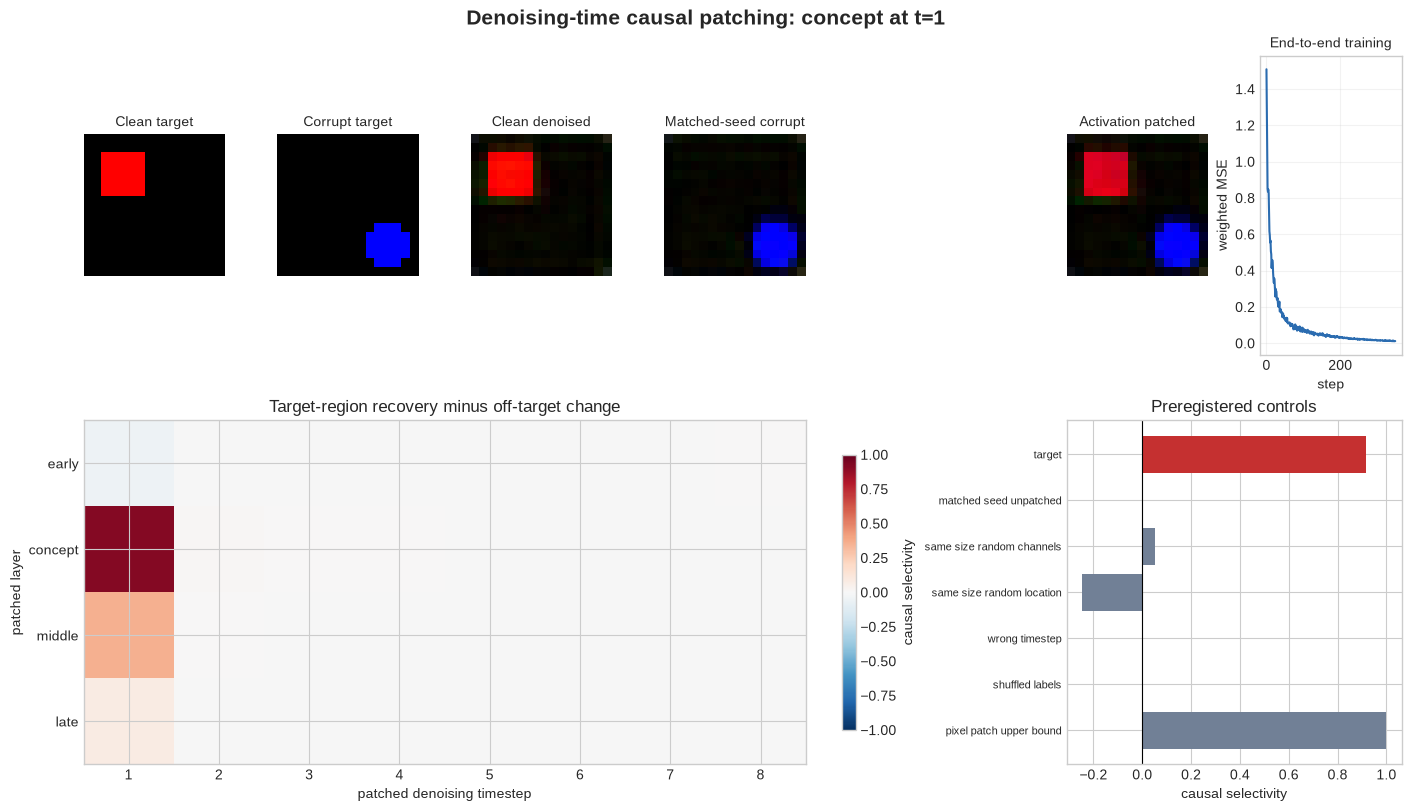

,condition,recovery,outside_change,selectivity
0,target,0.962,0.044,0.918
1,matched_seed_unpatched,0.000,0.000,0.000
2,same_size_random_channels,0.070,0.016,0.053
3,same_size_random_location,0.000,0.248,-0.248
4,wrong_timestep,0.000,0.000,-0.000
5,shuffled_labels,0.000,0.000,0.000
6,pixel_patch_upper_bound,1.000,0.000,1.000


In [9]:
toy_started = time.perf_counter()
toy_model, toy_trace = reference.train_object_denoiser(steps=350, seed=0)
toy_schedule = make_diffusion_schedule()
toy_clean_labels = t.tensor([[0, 0, 0, 0]])
toy_corrupt_labels = t.tensor([[1, 2, 1, 1]])
toy_noise = t.randn(1, 3, 16, 16, generator=t.Generator().manual_seed(2026))
toy_result = causal_patch_sweep(
    toy_model, toy_clean_labels, toy_corrupt_labels, toy_noise, toy_schedule
)
toy_result.update(
    training_trace=toy_trace,
    runtime_seconds=time.perf_counter() - toy_started,
    accepted=True,
)
toy_figure = reference.plot_signature_result(
    toy_result, assets_dir / "denoising_time_toy_signature.png"
)
plt.show()
toy_rows = [
    {"condition": "target", **asdict(toy_result["best_metric"])},
    *[
        {"condition": name, **asdict(metric)}
        for name, metric in toy_result["controls"].items()
    ],
]
display(pd.DataFrame(toy_rows).style.format(precision=3))


## Signature Result 1: The Method Finds the Planted Circuit

![Expected exact toy causal-patching result](../../instructions/assets/denoising_time_toy_signature.png)

<details>
<summary>Expected metrics</summary>

```text
training loss ratio: about 0.0215
best layer, timestep: concept, 1
best recovery: about 0.9621
best selectivity: about 0.9180
random channels: about 0.0533
wrong location: about -0.2480
wrong timestep: about -0.0002
shuffled labels: about 0.0002
pixel-patch upper bound: 1.0000
```
</details>

<details>
<summary>Interpretation - read the whole figure</summary>

The activation patch adds the red square at the clean object's location while leaving the blue corrupt object visible. The heatmap is sharply localized to the concept block at the final denoising call. A displaced patch changes the wrong pixels, and a pixel-space copy provides the explicit upper bound.
</details>

## Try It Yourself

Change the layer, timestep, channels, or spatial mask. Your explanation should predict which edits recover the target and which merely damage the image.


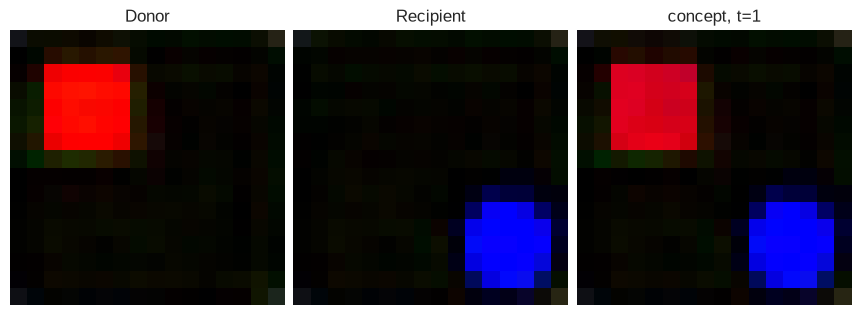

RegionalCausalMetric(recovery=0.9620839357376099, outside_change=0.044091030955314636, selectivity=0.9179929047822952)

In [10]:
PLAY_LAYER = "concept"
PLAY_TIMESTEP = 1
PLAY_CHANNELS = t.arange(toy_model.concept_channels)
PLAY_MASK_SHIFT = (0, 0)

play_mask = t.roll(
    toy_result["target_mask"], shifts=PLAY_MASK_SHIFT, dims=(-2, -1)
)
play_cache = ActivationCache(values={})
denoise_trajectory(
    toy_model, toy_clean_labels, toy_noise, toy_schedule, cache=play_cache
)
play_image = _patch_result(
    toy_model,
    toy_corrupt_labels,
    toy_noise,
    toy_schedule,
    play_cache,
    layer=PLAY_LAYER,
    apply_timestep=PLAY_TIMESTEP,
    donor_timestep=PLAY_TIMESTEP,
    channels=PLAY_CHANNELS,
    mask=play_mask,
)
play_metric = regional_causal_metric(
    toy_result["clean_target"],
    toy_result["corrupt_generated"],
    play_image,
    toy_result["target_mask"],
)
fig, axes = plt.subplots(1, 3, figsize=(8.5, 3), constrained_layout=True)
for axis, image, title in zip(
    axes,
    [toy_result["clean_generated"], toy_result["corrupt_generated"], play_image],
    ["Donor", "Recipient", f"{PLAY_LAYER}, t={PLAY_TIMESTEP}"],
):
    axis.imshow((image[0].permute(1, 2, 0).clamp(-1, 1) + 1) / 2)
    axis.set_title(title)
    axis.axis("off")
plt.show()
play_metric


## Part 2: Pinned Stable Diffusion 1.5

The real experiment changes only color within each pair: red vs blue square, and blue vs red circle. Every run starts from the identical seed and initial latent. You will write the DDIM loop and insert a donor latent exactly once.

The checkpoint loaders are plumbing from 13.1. The denoising loop, latent replacement, timestep sweep, CLIP contrast, regional metric, and controls remain learner-visible here.

### Exercise 8: Define a Spatially Isolated Latent Intervention

> Difficulty: 🔴🔴🔴⚪⚪ | Importance: 🔵🔵🔵🔵🔵 | 25 minutes

Implement a centered preregistered mask, donor replacement, scale-matched random replacement, donor/recipient calibration, and regional transfer metric. The unselected complement must remain bit-exact.


In [11]:
def make_center_mask(
    height: int,
    width: int,
    *,
    fraction: float = 0.5,
    device: t.device | str = "cpu",
) -> Tensor:
    """Return a preregistered centered spatial mask."""
    if height < 2 or width < 2:
        raise ValueError("height and width must both be at least two.")
    if not 0.0 < fraction < 1.0:
        raise ValueError("fraction must lie strictly between zero and one.")
    selected_height = max(1, round(height * fraction))
    selected_width = max(1, round(width * fraction))
    row_start = (height - selected_height) // 2
    column_start = (width - selected_width) // 2
    mask = t.zeros(height, width, dtype=t.bool, device=device)
    mask[
        row_start : row_start + selected_height,
        column_start : column_start + selected_width,
    ] = True
    return mask


def _broadcast_spatial_mask(mask: Tensor, tensor: Tensor) -> Tensor:
    if tensor.ndim != 4:
        raise ValueError("tensor must have shape [batch, channels, height, width].")
    mask = mask.to(device=tensor.device, dtype=t.bool)
    if mask.ndim == 2:
        mask = mask[None, None]
    elif mask.ndim == 3:
        mask = mask[:, None]
    if mask.shape[-2:] != tensor.shape[-2:]:
        raise ValueError("spatial_mask must match the tensor's spatial dimensions.")
    if mask.shape[0] not in (1, tensor.shape[0]):
        raise ValueError("spatial_mask batch must be one or match the tensor batch.")
    return mask.expand(tensor.shape[0], tensor.shape[1], -1, -1)


def apply_latent_patch(
    recipient: Tensor,
    donor: Tensor,
    spatial_mask: Tensor,
    *,
    mix: float = 1.0,
) -> Tensor:
    """Replace a selected latent region while leaving its complement bit-exact."""
    if recipient.shape != donor.shape:
        raise ValueError("recipient and donor latents must have identical shapes.")
    if not 0.0 <= mix <= 1.0:
        raise ValueError("mix must lie in [0, 1].")
    selector = _broadcast_spatial_mask(spatial_mask, recipient)
    replacement = recipient.lerp(donor.to(recipient), mix)
    return t.where(selector, replacement, recipient)


def apply_random_latent_patch(
    recipient: Tensor,
    donor: Tensor,
    spatial_mask: Tensor,
    *,
    seed: int,
) -> Tensor:
    """Apply a same-size Gaussian control matched to donor-region mean and scale."""
    if recipient.shape != donor.shape:
        raise ValueError("recipient and donor latents must have identical shapes.")
    selector = _broadcast_spatial_mask(spatial_mask, recipient)
    donor_values = donor.to(recipient)[selector]
    if donor_values.numel() < 2:
        raise ValueError("spatial_mask must select at least two latent values.")
    generator = t.Generator(device=recipient.device).manual_seed(seed)
    noise = t.randn(
        recipient.shape,
        dtype=recipient.dtype,
        device=recipient.device,
        generator=generator,
    )
    noise = noise * donor_values.float().std().to(recipient.dtype)
    noise = noise + donor_values.float().mean().to(recipient.dtype)
    return t.where(selector, noise, recipient)


def calibrated_recovery(
    recipient_score: float,
    donor_score: float,
    patched_score: float,
) -> float:
    """Calibrate recipient to zero and donor to one on an oriented scalar score."""
    denominator = donor_score - recipient_score
    if abs(denominator) < 1e-8:
        raise ValueError("donor and recipient scores must define a nonzero contrast.")
    return (patched_score - recipient_score) / denominator


def latent_transfer_metric(
    donor_image: Tensor,
    recipient_image: Tensor,
    patched_image: Tensor,
    spatial_mask: Tensor,
) -> LatentTransferMetric:
    """Measure donor recovery inside a region and recipient preservation outside it."""
    if donor_image.shape != recipient_image.shape or donor_image.shape != patched_image.shape:
        raise ValueError("all images must have identical [batch, channels, height, width] shapes.")
    selector = _broadcast_spatial_mask(spatial_mask, donor_image)
    outside = ~selector
    donor_distance = (
        (recipient_image[selector] - donor_image[selector]).square().mean().sqrt().item()
    )
    patched_distance = (
        (patched_image[selector] - donor_image[selector]).square().mean().sqrt().item()
    )
    recovery = 1.0 - patched_distance / max(donor_distance, 1e-8)
    recipient_distance = (
        (patched_image[selector] - recipient_image[selector]).square().mean().sqrt().item()
    )
    outside_change = (
        (patched_image[outside] - recipient_image[outside]).square().mean().sqrt().item()
        if outside.any()
        else 0.0
    )
    return LatentTransferMetric(
        donor_distance=donor_distance,
        recipient_distance=recipient_distance,
        recovery=recovery,
        outside_change=outside_change,
        selectivity=recovery - outside_change,
    )


tests.test_center_mask_is_preregistered_and_centered(make_center_mask)
tests.test_latent_patch_preserves_the_complement_exactly(apply_latent_patch)
tests.test_random_latent_patch_is_seeded_and_same_size(apply_random_latent_patch)
tests.test_calibrated_recovery_anchors_recipient_and_donor(calibrated_recovery)
tests.test_latent_transfer_metric_rewards_regional_transfer(latent_transfer_metric)


All tests in `test_center_mask_is_preregistered_and_centered` passed!
All tests in `test_latent_patch_preserves_the_complement_exactly` passed!
All tests in `test_random_latent_patch_is_seeded_and_same_size` passed!
All tests in `test_calibrated_recovery_anchors_recipient_and_donor` passed!
All tests in `test_latent_transfer_metric_rewards_regional_transfer` passed!


<details>
        <summary>Expected output</summary>

        ```text
        Five visible test groups pass; recipient recovery is exactly 0, donor recovery exactly 1, and the patch complement is unchanged.
        ```
        </details>

        <details>
        <summary>Help - getting started</summary>

        Expand a two-dimensional mask to batch and channels only after validating its spatial shape. Calibrate any oriented score as `(patched - recipient) / (donor - recipient)`.
        </details>

        <details>
        <summary>Common bugs</summary>

        - using a generated segmentation as the intervention mask
- normalizing random noise differently from donor state
- allowing the outside region to change without penalty
        </details>

        <details>
        <summary>Interpretation</summary>

        The CLIP recovery and pixel recovery have different failure modes. Keeping both visible prevents a semantic score from hiding global image damage.
        </details>

        <details>
        <summary>Solution</summary>

        ```python
        def make_center_mask(
    height: int,
    width: int,
    *,
    fraction: float = 0.5,
    device: t.device | str = "cpu",
) -> Tensor:
    """Return a preregistered centered spatial mask."""
    if height < 2 or width < 2:
        raise ValueError("height and width must both be at least two.")
    if not 0.0 < fraction < 1.0:
        raise ValueError("fraction must lie strictly between zero and one.")
    selected_height = max(1, round(height * fraction))
    selected_width = max(1, round(width * fraction))
    row_start = (height - selected_height) // 2
    column_start = (width - selected_width) // 2
    mask = t.zeros(height, width, dtype=t.bool, device=device)
    mask[
        row_start : row_start + selected_height,
        column_start : column_start + selected_width,
    ] = True
    return mask


def _broadcast_spatial_mask(mask: Tensor, tensor: Tensor) -> Tensor:
    if tensor.ndim != 4:
        raise ValueError("tensor must have shape [batch, channels, height, width].")
    mask = mask.to(device=tensor.device, dtype=t.bool)
    if mask.ndim == 2:
        mask = mask[None, None]
    elif mask.ndim == 3:
        mask = mask[:, None]
    if mask.shape[-2:] != tensor.shape[-2:]:
        raise ValueError("spatial_mask must match the tensor's spatial dimensions.")
    if mask.shape[0] not in (1, tensor.shape[0]):
        raise ValueError("spatial_mask batch must be one or match the tensor batch.")
    return mask.expand(tensor.shape[0], tensor.shape[1], -1, -1)


def apply_latent_patch(
    recipient: Tensor,
    donor: Tensor,
    spatial_mask: Tensor,
    *,
    mix: float = 1.0,
) -> Tensor:
    """Replace a selected latent region while leaving its complement bit-exact."""
    if recipient.shape != donor.shape:
        raise ValueError("recipient and donor latents must have identical shapes.")
    if not 0.0 <= mix <= 1.0:
        raise ValueError("mix must lie in [0, 1].")
    selector = _broadcast_spatial_mask(spatial_mask, recipient)
    replacement = recipient.lerp(donor.to(recipient), mix)
    return t.where(selector, replacement, recipient)


def apply_random_latent_patch(
    recipient: Tensor,
    donor: Tensor,
    spatial_mask: Tensor,
    *,
    seed: int,
) -> Tensor:
    """Apply a same-size Gaussian control matched to donor-region mean and scale."""
    if recipient.shape != donor.shape:
        raise ValueError("recipient and donor latents must have identical shapes.")
    selector = _broadcast_spatial_mask(spatial_mask, recipient)
    donor_values = donor.to(recipient)[selector]
    if donor_values.numel() < 2:
        raise ValueError("spatial_mask must select at least two latent values.")
    generator = t.Generator(device=recipient.device).manual_seed(seed)
    noise = t.randn(
        recipient.shape,
        dtype=recipient.dtype,
        device=recipient.device,
        generator=generator,
    )
    noise = noise * donor_values.float().std().to(recipient.dtype)
    noise = noise + donor_values.float().mean().to(recipient.dtype)
    return t.where(selector, noise, recipient)


def calibrated_recovery(
    recipient_score: float,
    donor_score: float,
    patched_score: float,
) -> float:
    """Calibrate recipient to zero and donor to one on an oriented scalar score."""
    denominator = donor_score - recipient_score
    if abs(denominator) < 1e-8:
        raise ValueError("donor and recipient scores must define a nonzero contrast.")
    return (patched_score - recipient_score) / denominator


def latent_transfer_metric(
    donor_image: Tensor,
    recipient_image: Tensor,
    patched_image: Tensor,
    spatial_mask: Tensor,
) -> LatentTransferMetric:
    """Measure donor recovery inside a region and recipient preservation outside it."""
    if donor_image.shape != recipient_image.shape or donor_image.shape != patched_image.shape:
        raise ValueError("all images must have identical [batch, channels, height, width] shapes.")
    selector = _broadcast_spatial_mask(spatial_mask, donor_image)
    outside = ~selector
    donor_distance = (
        (recipient_image[selector] - donor_image[selector]).square().mean().sqrt().item()
    )
    patched_distance = (
        (patched_image[selector] - donor_image[selector]).square().mean().sqrt().item()
    )
    recovery = 1.0 - patched_distance / max(donor_distance, 1e-8)
    recipient_distance = (
        (patched_image[selector] - recipient_image[selector]).square().mean().sqrt().item()
    )
    outside_change = (
        (patched_image[outside] - recipient_image[outside]).square().mean().sqrt().item()
        if outside.any()
        else 0.0
    )
    return LatentTransferMetric(
        donor_distance=donor_distance,
        recipient_distance=recipient_distance,
        recovery=recovery,
        outside_change=outside_change,
        selectivity=recovery - outside_change,
    )

        ```
        </details>


### Exercise 9: Write Stable Diffusion's DDIM Loop

> Difficulty: 🔴🔴🔴🔴🔴 | Importance: 🔵🔵🔵🔵🔵 | 40 minutes

Encode classifier-free guidance in UNet batch order, prepare the fixed initial latent, execute each scheduler update, and insert one donor state **before** exactly one UNet call. Return the decoded image and every latent state.


In [12]:
def encode_sd15_prompt(
    pipe,
    prompt: str,
    negative_prompt: str,
    *,
    device: str | t.device,
) -> Tensor:
    """Encode one classifier-free-guidance prompt in UNet batch order."""
    prompt_embeds, negative_prompt_embeds = pipe.encode_prompt(
        prompt=prompt,
        device=device,
        num_images_per_prompt=1,
        do_classifier_free_guidance=True,
        negative_prompt=negative_prompt,
    )
    if negative_prompt_embeds is None:
        raise RuntimeError("classifier-free guidance requires negative prompt embeddings.")
    return t.cat([negative_prompt_embeds, prompt_embeds])


def prepare_same_seed_sd15_latents(
    pipe,
    *,
    seed: int,
    device: str | t.device,
    height: int = 512,
    width: int = 512,
) -> Tensor:
    """Create the exact initial latent shared by donor, recipient, and controls."""
    device = t.device(device)
    generator = t.Generator(device=device).manual_seed(seed)
    return pipe.prepare_latents(
        batch_size=1,
        num_channels_latents=pipe.unet.config.in_channels,
        height=height,
        width=width,
        dtype=pipe.unet.dtype,
        device=device,
        generator=generator,
    )


def decode_sd15_latents(pipe, latents: Tensor) -> tuple[Any, Tensor]:
    """Decode one latent to both a PIL image and a [1, 3, H, W] float tensor."""
    scaled = latents / pipe.vae.config.scaling_factor
    decoded = pipe.vae.decode(scaled, return_dict=False)[0]
    image = pipe.image_processor.postprocess(decoded, output_type="pil")[0]
    width, height = image.size
    image_tensor = (
        t.tensor(list(image.convert("RGB").getdata()), dtype=t.float32)
        .reshape(height, width, 3)
        .permute(2, 0, 1)[None]
        / 255.0
    )
    return image, image_tensor


@t.inference_mode()
def run_sd15_latent_trajectory(
    pipe,
    prompt: str,
    negative_prompt: str,
    initial_latents: Tensor,
    *,
    num_inference_steps: int = 20,
    guidance_scale: float = 9.0,
    patch_step_index: int | None = None,
    donor_states: tuple[Tensor, ...] | None = None,
    spatial_mask: Tensor | None = None,
    patch_kind: Literal["donor", "random"] = "donor",
    patch_mix: float = 1.0,
    random_seed: int = 0,
    cache_states: bool = True,
) -> SD15Trajectory:
    """Run the explicit DDIM loop, optionally replacing one latent state."""
    if num_inference_steps < 2:
        raise ValueError("num_inference_steps must be at least two.")
    device = initial_latents.device
    prompt_embeds = encode_sd15_prompt(
        pipe, prompt, negative_prompt, device=device
    )
    pipe.scheduler.set_timesteps(num_inference_steps, device=device)
    timesteps = tuple(int(step.item()) for step in pipe.scheduler.timesteps)
    if patch_step_index is not None:
        if not 0 <= patch_step_index < num_inference_steps:
            raise ValueError("patch_step_index must index a denoising model call.")
        if donor_states is None or len(donor_states) != num_inference_steps + 1:
            raise ValueError("donor_states must contain the initial state and every DDIM update.")
        if spatial_mask is None:
            raise ValueError("spatial_mask is required when patching.")
    latents = initial_latents.clone()
    states: list[Tensor] = [latents.detach().clone()] if cache_states else []
    for step_index, timestep in enumerate(pipe.scheduler.timesteps):
        if step_index == patch_step_index:
            donor = donor_states[step_index].to(latents)
            if patch_kind == "donor":
                latents = apply_latent_patch(
                    latents, donor, spatial_mask, mix=patch_mix
                )
            elif patch_kind == "random":
                latents = apply_random_latent_patch(
                    latents, donor, spatial_mask, seed=random_seed
                )
            else:
                raise ValueError("patch_kind must be 'donor' or 'random'.")
        model_input = t.cat([latents, latents])
        model_input = pipe.scheduler.scale_model_input(model_input, timestep)
        noise_prediction = pipe.unet(
            model_input,
            timestep,
            encoder_hidden_states=prompt_embeds,
            return_dict=False,
        )[0]
        noise_unconditional, noise_conditional = noise_prediction.chunk(2)
        guided_noise = noise_unconditional + guidance_scale * (
            noise_conditional - noise_unconditional
        )
        latents = pipe.scheduler.step(
            guided_noise,
            timestep,
            latents,
            eta=0.0,
            return_dict=False,
        )[0]
        if cache_states:
            states.append(latents.detach().clone())
    image, image_tensor = decode_sd15_latents(pipe, latents)
    return SD15Trajectory(
        image=image,
        image_tensor=image_tensor,
        latent_states=tuple(states),
        scheduler_timesteps=timesteps,
    )


tests.test_sd15_trajectory_rejects_invalid_step_count(run_sd15_latent_trajectory)


All tests in `test_sd15_trajectory_rejects_invalid_step_count` passed!


<details>
        <summary>Expected output</summary>

        ```text
        All tests in `test_sd15_trajectory_rejects_invalid_step_count` passed; the CUDA run later returns 21 states for 20 denoising calls.
        ```
        </details>

        <details>
        <summary>Help - getting started</summary>

        Patch `latents` at the top of the chosen loop iteration. Duplicate latents for unconditional and conditional batches, combine the two noise predictions, then call `scheduler.step`.
        </details>

        <details>
        <summary>Common bugs</summary>

        - patching after the scheduler step while labeling the previous timestep
- using different initial latents
- forgetting scheduler input scaling
- mixing conditional and unconditional batch order
        </details>

        <details>
        <summary>Interpretation</summary>

        Patching before a denoising call asks whether the donor state at that moment can change the recipient's future computation. Patching only the final decoded pixels would not answer this question.
        </details>

        <details>
        <summary>Solution</summary>

        ```python
        def encode_sd15_prompt(
    pipe,
    prompt: str,
    negative_prompt: str,
    *,
    device: str | t.device,
) -> Tensor:
    """Encode one classifier-free-guidance prompt in UNet batch order."""
    prompt_embeds, negative_prompt_embeds = pipe.encode_prompt(
        prompt=prompt,
        device=device,
        num_images_per_prompt=1,
        do_classifier_free_guidance=True,
        negative_prompt=negative_prompt,
    )
    if negative_prompt_embeds is None:
        raise RuntimeError("classifier-free guidance requires negative prompt embeddings.")
    return t.cat([negative_prompt_embeds, prompt_embeds])


def prepare_same_seed_sd15_latents(
    pipe,
    *,
    seed: int,
    device: str | t.device,
    height: int = 512,
    width: int = 512,
) -> Tensor:
    """Create the exact initial latent shared by donor, recipient, and controls."""
    device = t.device(device)
    generator = t.Generator(device=device).manual_seed(seed)
    return pipe.prepare_latents(
        batch_size=1,
        num_channels_latents=pipe.unet.config.in_channels,
        height=height,
        width=width,
        dtype=pipe.unet.dtype,
        device=device,
        generator=generator,
    )


def decode_sd15_latents(pipe, latents: Tensor) -> tuple[Any, Tensor]:
    """Decode one latent to both a PIL image and a [1, 3, H, W] float tensor."""
    scaled = latents / pipe.vae.config.scaling_factor
    decoded = pipe.vae.decode(scaled, return_dict=False)[0]
    image = pipe.image_processor.postprocess(decoded, output_type="pil")[0]
    width, height = image.size
    image_tensor = (
        t.tensor(list(image.convert("RGB").getdata()), dtype=t.float32)
        .reshape(height, width, 3)
        .permute(2, 0, 1)[None]
        / 255.0
    )
    return image, image_tensor


@t.inference_mode()
def run_sd15_latent_trajectory(
    pipe,
    prompt: str,
    negative_prompt: str,
    initial_latents: Tensor,
    *,
    num_inference_steps: int = 20,
    guidance_scale: float = 9.0,
    patch_step_index: int | None = None,
    donor_states: tuple[Tensor, ...] | None = None,
    spatial_mask: Tensor | None = None,
    patch_kind: Literal["donor", "random"] = "donor",
    patch_mix: float = 1.0,
    random_seed: int = 0,
    cache_states: bool = True,
) -> SD15Trajectory:
    """Run the explicit DDIM loop, optionally replacing one latent state."""
    if num_inference_steps < 2:
        raise ValueError("num_inference_steps must be at least two.")
    device = initial_latents.device
    prompt_embeds = encode_sd15_prompt(
        pipe, prompt, negative_prompt, device=device
    )
    pipe.scheduler.set_timesteps(num_inference_steps, device=device)
    timesteps = tuple(int(step.item()) for step in pipe.scheduler.timesteps)
    if patch_step_index is not None:
        if not 0 <= patch_step_index < num_inference_steps:
            raise ValueError("patch_step_index must index a denoising model call.")
        if donor_states is None or len(donor_states) != num_inference_steps + 1:
            raise ValueError("donor_states must contain the initial state and every DDIM update.")
        if spatial_mask is None:
            raise ValueError("spatial_mask is required when patching.")
    latents = initial_latents.clone()
    states: list[Tensor] = [latents.detach().clone()] if cache_states else []
    for step_index, timestep in enumerate(pipe.scheduler.timesteps):
        if step_index == patch_step_index:
            donor = donor_states[step_index].to(latents)
            if patch_kind == "donor":
                latents = apply_latent_patch(
                    latents, donor, spatial_mask, mix=patch_mix
                )
            elif patch_kind == "random":
                latents = apply_random_latent_patch(
                    latents, donor, spatial_mask, seed=random_seed
                )
            else:
                raise ValueError("patch_kind must be 'donor' or 'random'.")
        model_input = t.cat([latents, latents])
        model_input = pipe.scheduler.scale_model_input(model_input, timestep)
        noise_prediction = pipe.unet(
            model_input,
            timestep,
            encoder_hidden_states=prompt_embeds,
            return_dict=False,
        )[0]
        noise_unconditional, noise_conditional = noise_prediction.chunk(2)
        guided_noise = noise_unconditional + guidance_scale * (
            noise_conditional - noise_unconditional
        )
        latents = pipe.scheduler.step(
            guided_noise,
            timestep,
            latents,
            eta=0.0,
            return_dict=False,
        )[0]
        if cache_states:
            states.append(latents.detach().clone())
    image, image_tensor = decode_sd15_latents(pipe, latents)
    return SD15Trajectory(
        image=image,
        image_tensor=image_tensor,
        latent_states=tuple(states),
        scheduler_timesteps=timesteps,
    )

        ```
        </details>


### Exercise 10: Sweep Time and Falsify the Real Claim

> Difficulty: 🔴🔴🔴🔴🔴 | Importance: 🔵🔵🔵🔵🔵 | 45 minutes

Decode one donor patch at every denoising call. Select the maximum CLIP donor recovery, then evaluate the same chosen time with a displaced region and a scale-matched random latent. The opposite schedule endpoint is the wrong-time control, and the unpatched recipient is fixed to zero recovery.


In [13]:
@t.inference_mode()
def clip_donor_margins(
    clip_model,
    clip_processor,
    images: list[Any],
    *,
    donor_text: str,
    recipient_text: str,
    device: str | t.device,
) -> Tensor:
    """Return CLIP donor-minus-recipient logits for every generated image."""
    inputs = clip_processor(
        text=[donor_text, recipient_text],
        images=images,
        return_tensors="pt",
        padding=True,
    ).to(device)
    logits = clip_model(**inputs).logits_per_image.detach().float().cpu()
    if logits.shape != (len(images), 2):
        raise RuntimeError("CLIP should return one donor/recipient logit pair per image.")
    return logits[:, 0] - logits[:, 1]


def _wrong_region_mask(mask: Tensor) -> Tensor:
    return t.roll(mask, shifts=(mask.shape[-2] // 2, mask.shape[-1] // 2), dims=(-2, -1))


@t.inference_mode()
def run_sd15_patch_case(
    pipe,
    clip_model,
    clip_processor,
    case: dict[str, Any],
    *,
    device: str | t.device,
    num_inference_steps: int = 20,
    guidance_scale: float = 9.0,
    patch_fraction: float = 0.5,
) -> dict[str, Any]:
    """Sweep a real same-seed donor latent over denoising time and controls."""
    device = t.device(device)
    initial = prepare_same_seed_sd15_latents(
        pipe, seed=int(case["seed"]), device=device
    )
    latent_mask = make_center_mask(
        initial.shape[-2], initial.shape[-1], fraction=patch_fraction, device=device
    )
    image_mask = make_center_mask(512, 512, fraction=patch_fraction)[None]
    donor = run_sd15_latent_trajectory(
        pipe,
        str(case["donor_prompt"]),
        REAL_SD15_NEGATIVE_PROMPT,
        initial,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
    )
    recipient = run_sd15_latent_trajectory(
        pipe,
        str(case["recipient_prompt"]),
        REAL_SD15_NEGATIVE_PROMPT,
        initial,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
    )
    patched: list[SD15Trajectory] = []
    for step_index in range(1, num_inference_steps):
        patched.append(
            run_sd15_latent_trajectory(
                pipe,
                str(case["recipient_prompt"]),
                REAL_SD15_NEGATIVE_PROMPT,
                initial,
                num_inference_steps=num_inference_steps,
                guidance_scale=guidance_scale,
                patch_step_index=step_index,
                donor_states=donor.latent_states,
                spatial_mask=latent_mask,
                cache_states=False,
            )
        )
    sweep_images = [donor.image, recipient.image] + [item.image for item in patched]
    sweep_margins = clip_donor_margins(
        clip_model,
        clip_processor,
        sweep_images,
        donor_text=str(case["donor_text"]),
        recipient_text=str(case["recipient_text"]),
        device=device,
    )
    donor_margin = float(sweep_margins[0])
    recipient_margin = float(sweep_margins[1])
    clip_recoveries = [
        calibrated_recovery(recipient_margin, donor_margin, float(score))
        for score in sweep_margins[2:]
    ]
    regional_metrics = [
        latent_transfer_metric(
            donor.image_tensor,
            recipient.image_tensor,
            item.image_tensor,
            image_mask,
        )
        for item in patched
    ]
    best_offset = max(range(len(clip_recoveries)), key=clip_recoveries.__getitem__)
    best_step = best_offset + 1
    best = patched[best_offset]
    wrong_step = 1 if best_step >= num_inference_steps // 2 else num_inference_steps - 1
    wrong_time = patched[wrong_step - 1]
    wrong_region = run_sd15_latent_trajectory(
        pipe,
        str(case["recipient_prompt"]),
        REAL_SD15_NEGATIVE_PROMPT,
        initial,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        patch_step_index=best_step,
        donor_states=donor.latent_states,
        spatial_mask=_wrong_region_mask(latent_mask),
        cache_states=False,
    )
    random_latent = run_sd15_latent_trajectory(
        pipe,
        str(case["recipient_prompt"]),
        REAL_SD15_NEGATIVE_PROMPT,
        initial,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        patch_step_index=best_step,
        donor_states=donor.latent_states,
        spatial_mask=latent_mask,
        patch_kind="random",
        random_seed=1000 + int(case["seed"]),
        cache_states=False,
    )
    control_images = [wrong_region.image, random_latent.image]
    control_margins = clip_donor_margins(
        clip_model,
        clip_processor,
        control_images,
        donor_text=str(case["donor_text"]),
        recipient_text=str(case["recipient_text"]),
        device=device,
    )
    wrong_timestep_recovery = clip_recoveries[wrong_step - 1]
    wrong_region_recovery = calibrated_recovery(
        recipient_margin, donor_margin, float(control_margins[0])
    )
    random_recovery = calibrated_recovery(
        recipient_margin, donor_margin, float(control_margins[1])
    )
    best_recovery = clip_recoveries[best_offset]
    controls = [0.0, wrong_timestep_recovery, wrong_region_recovery, random_recovery]
    target_beats_controls = best_recovery >= max(controls) + 0.05
    report = SD15PatchControlReport(
        best_step_index=best_step,
        best_scheduler_timestep=donor.scheduler_timesteps[best_step],
        best_clip_recovery=best_recovery,
        best_regional_selectivity=regional_metrics[best_offset].selectivity,
        wrong_timestep_recovery=wrong_timestep_recovery,
        wrong_region_recovery=wrong_region_recovery,
        random_latent_recovery=random_recovery,
        unpatched_recovery=0.0,
        target_beats_controls=target_beats_controls,
    )
    return {
        "case": dict(case),
        "donor": donor,
        "recipient": recipient,
        "patched_sweep": patched,
        "clip_recoveries": clip_recoveries,
        "regional_metrics": regional_metrics,
        "best": best,
        "wrong_timestep": wrong_time,
        "wrong_region": wrong_region,
        "random_latent": random_latent,
        "report": report,
        "latent_mask": latent_mask.detach().cpu(),
        "image_mask": image_mask.detach().cpu(),
    }


tests.test_real_sd15_case_contract_is_pinned_and_counterfactual()


<details>
        <summary>Expected output</summary>

        ```text
        The two pinned counterfactual contracts pass on CPU. On CUDA, each case returns 19 intervention points plus wrong-region, random-latent, wrong-time, and unpatched controls.
        ```
        </details>

        <details>
        <summary>Help - getting started</summary>

        Batch CLIP scoring after generation. Choose the best index from the complete target sweep, not from controls. Reuse the exact donor state and selected timestep for the wrong-region intervention.
        </details>

        <details>
        <summary>Common bugs</summary>

        - choosing a control-specific best timestep
- changing seed between donor and recipient
- comparing raw CLIP logits across unrelated text pairs
- treating random-latent damage as concept transfer
        </details>

        <details>
        <summary>Interpretation</summary>

        The full curve answers when donor information is portable. Controls ask whether that effect is about the donor concept, the selected region, and the selected time rather than generic trajectory disruption.
        </details>

        <details>
        <summary>Solution</summary>

        ```python
        @t.inference_mode()
def clip_donor_margins(
    clip_model,
    clip_processor,
    images: list[Any],
    *,
    donor_text: str,
    recipient_text: str,
    device: str | t.device,
) -> Tensor:
    """Return CLIP donor-minus-recipient logits for every generated image."""
    inputs = clip_processor(
        text=[donor_text, recipient_text],
        images=images,
        return_tensors="pt",
        padding=True,
    ).to(device)
    logits = clip_model(**inputs).logits_per_image.detach().float().cpu()
    if logits.shape != (len(images), 2):
        raise RuntimeError("CLIP should return one donor/recipient logit pair per image.")
    return logits[:, 0] - logits[:, 1]


def _wrong_region_mask(mask: Tensor) -> Tensor:
    return t.roll(mask, shifts=(mask.shape[-2] // 2, mask.shape[-1] // 2), dims=(-2, -1))


@t.inference_mode()
def run_sd15_patch_case(
    pipe,
    clip_model,
    clip_processor,
    case: dict[str, Any],
    *,
    device: str | t.device,
    num_inference_steps: int = 20,
    guidance_scale: float = 9.0,
    patch_fraction: float = 0.5,
) -> dict[str, Any]:
    """Sweep a real same-seed donor latent over denoising time and controls."""
    device = t.device(device)
    initial = prepare_same_seed_sd15_latents(
        pipe, seed=int(case["seed"]), device=device
    )
    latent_mask = make_center_mask(
        initial.shape[-2], initial.shape[-1], fraction=patch_fraction, device=device
    )
    image_mask = make_center_mask(512, 512, fraction=patch_fraction)[None]
    donor = run_sd15_latent_trajectory(
        pipe,
        str(case["donor_prompt"]),
        REAL_SD15_NEGATIVE_PROMPT,
        initial,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
    )
    recipient = run_sd15_latent_trajectory(
        pipe,
        str(case["recipient_prompt"]),
        REAL_SD15_NEGATIVE_PROMPT,
        initial,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
    )
    patched: list[SD15Trajectory] = []
    for step_index in range(1, num_inference_steps):
        patched.append(
            run_sd15_latent_trajectory(
                pipe,
                str(case["recipient_prompt"]),
                REAL_SD15_NEGATIVE_PROMPT,
                initial,
                num_inference_steps=num_inference_steps,
                guidance_scale=guidance_scale,
                patch_step_index=step_index,
                donor_states=donor.latent_states,
                spatial_mask=latent_mask,
                cache_states=False,
            )
        )
    sweep_images = [donor.image, recipient.image] + [item.image for item in patched]
    sweep_margins = clip_donor_margins(
        clip_model,
        clip_processor,
        sweep_images,
        donor_text=str(case["donor_text"]),
        recipient_text=str(case["recipient_text"]),
        device=device,
    )
    donor_margin = float(sweep_margins[0])
    recipient_margin = float(sweep_margins[1])
    clip_recoveries = [
        calibrated_recovery(recipient_margin, donor_margin, float(score))
        for score in sweep_margins[2:]
    ]
    regional_metrics = [
        latent_transfer_metric(
            donor.image_tensor,
            recipient.image_tensor,
            item.image_tensor,
            image_mask,
        )
        for item in patched
    ]
    best_offset = max(range(len(clip_recoveries)), key=clip_recoveries.__getitem__)
    best_step = best_offset + 1
    best = patched[best_offset]
    wrong_step = 1 if best_step >= num_inference_steps // 2 else num_inference_steps - 1
    wrong_time = patched[wrong_step - 1]
    wrong_region = run_sd15_latent_trajectory(
        pipe,
        str(case["recipient_prompt"]),
        REAL_SD15_NEGATIVE_PROMPT,
        initial,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        patch_step_index=best_step,
        donor_states=donor.latent_states,
        spatial_mask=_wrong_region_mask(latent_mask),
        cache_states=False,
    )
    random_latent = run_sd15_latent_trajectory(
        pipe,
        str(case["recipient_prompt"]),
        REAL_SD15_NEGATIVE_PROMPT,
        initial,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        patch_step_index=best_step,
        donor_states=donor.latent_states,
        spatial_mask=latent_mask,
        patch_kind="random",
        random_seed=1000 + int(case["seed"]),
        cache_states=False,
    )
    control_images = [wrong_region.image, random_latent.image]
    control_margins = clip_donor_margins(
        clip_model,
        clip_processor,
        control_images,
        donor_text=str(case["donor_text"]),
        recipient_text=str(case["recipient_text"]),
        device=device,
    )
    wrong_timestep_recovery = clip_recoveries[wrong_step - 1]
    wrong_region_recovery = calibrated_recovery(
        recipient_margin, donor_margin, float(control_margins[0])
    )
    random_recovery = calibrated_recovery(
        recipient_margin, donor_margin, float(control_margins[1])
    )
    best_recovery = clip_recoveries[best_offset]
    controls = [0.0, wrong_timestep_recovery, wrong_region_recovery, random_recovery]
    target_beats_controls = best_recovery >= max(controls) + 0.05
    report = SD15PatchControlReport(
        best_step_index=best_step,
        best_scheduler_timestep=donor.scheduler_timesteps[best_step],
        best_clip_recovery=best_recovery,
        best_regional_selectivity=regional_metrics[best_offset].selectivity,
        wrong_timestep_recovery=wrong_timestep_recovery,
        wrong_region_recovery=wrong_region_recovery,
        random_latent_recovery=random_recovery,
        unpatched_recovery=0.0,
        target_beats_controls=target_beats_controls,
    )
    return {
        "case": dict(case),
        "donor": donor,
        "recipient": recipient,
        "patched_sweep": patched,
        "clip_recoveries": clip_recoveries,
        "regional_metrics": regional_metrics,
        "best": best,
        "wrong_timestep": wrong_time,
        "wrong_region": wrong_region,
        "random_latent": random_latent,
        "report": report,
        "latent_mask": latent_mask.detach().cpu(),
        "image_mask": image_mask.detach().cpu(),
    }

        ```
        </details>


## Signature Result 2: Real SD1.5 Denoising-Time Causality

The pinned CUDA 13.2 release run found best CLIP recoveries of `0.654` and
`0.505` on the two color counterfactuals, with regional selectivity `0.222` in
both cases. The target interventions beat their strongest matched controls by
`0.194` and `0.213` at `3.235 GiB` peak VRAM.

![Pinned SD1.5 denoising-time intervention sweep](../../instructions/assets/denoising_time_sd15_signature.png)

Run the next cell on CUDA to reproduce the figure from your explicit loop and
case sweep. The committed image is an expected-output reference; no
verification report supplies the plotted result.


W0904 23:32:04.481000 2086749 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W0904 23:32:04.491000 2086749 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

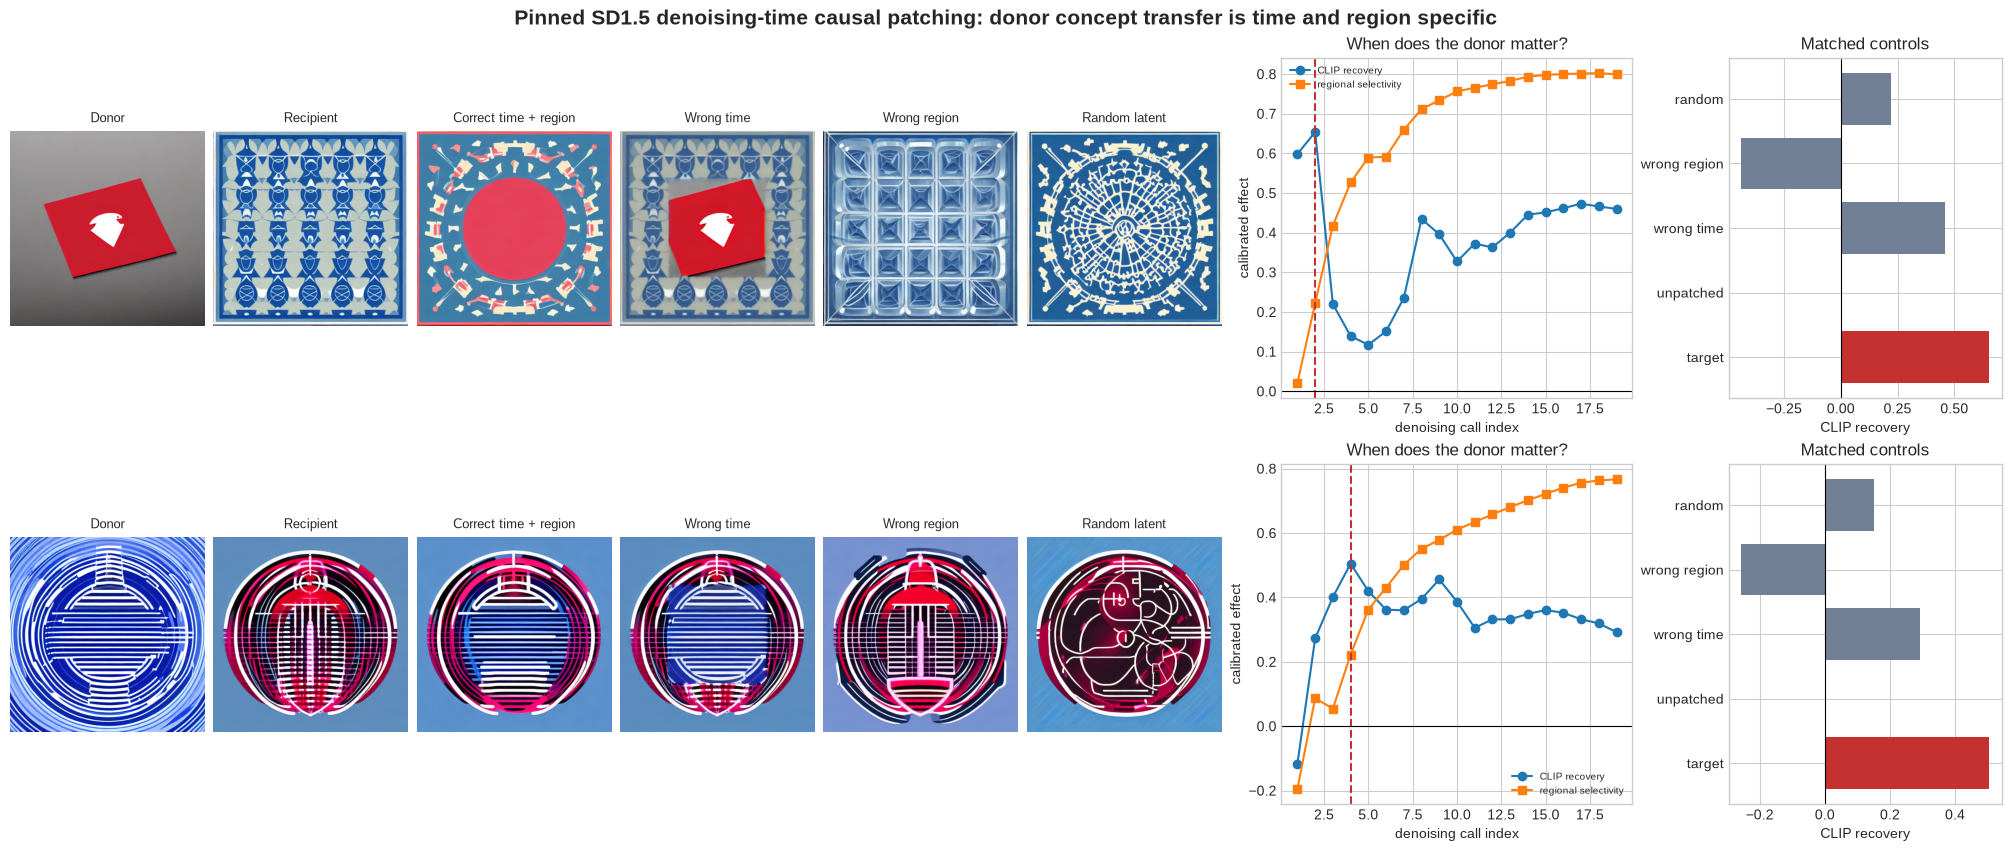

,case,best_step_index,best_scheduler_timestep,best_clip_recovery,best_regional_selectivity,wrong_timestep_recovery,wrong_region_recovery,random_latent_recovery,unpatched_recovery,target_beats_controls
0,red_into_blue_square,2,851,0.654,0.222,0.460,-0.439,0.221,0.000,True
1,blue_into_red_circle,4,751,0.505,0.222,0.292,-0.257,0.151,0.000,True


stable-diffusion-v1-5/stable-diffusion-v1-5 | NVIDIA GeForce RTX 5090 Laptop GPU | CUDA 13.2 | peak VRAM 3.203 GiB
All tests in `validate_real_sd15_signature` passed!


In [14]:
if not t.cuda.is_available():
    raise RuntimeError("The real SD1.5 signature requires CUDA; there is no CPU fallback.")
device = t.device("cuda")
t.cuda.empty_cache()
t.cuda.reset_peak_memory_stats()
real_started = time.perf_counter()
pipe = reference.load_pinned_sd15_ddim_pipeline(device)
clip_model, clip_processor = reference.load_pinned_clip_components(device)
real_cases = [
    run_sd15_patch_case(
        pipe, clip_model, clip_processor, case, device=device,
        num_inference_steps=20,
    )
    for case in reference.REAL_SD15_CASES
]
t.cuda.synchronize()
real_result = {
    "model_id": reference.REAL_SD15_MODEL_ID,
    "revision": reference.REAL_SD15_REVISION,
    "clip_model_id": reference.REAL_CLIP_MODEL_ID,
    "clip_revision": reference.REAL_CLIP_REVISION,
    "torch_version": t.__version__,
    "cuda_version": t.version.cuda,
    "gpu_name": t.cuda.get_device_name(),
    "num_inference_steps": 20,
    "cases": real_cases,
    "peak_vram_gb": t.cuda.max_memory_allocated() / 2**30,
    "runtime_seconds": time.perf_counter() - real_started,
}
real_result["within_vram_budget"] = real_result["peak_vram_gb"] <= 24.0
real_result["accepted"] = (
    real_result["within_vram_budget"]
    and all(case["report"].target_beats_controls for case in real_cases)
    and all(case["report"].best_clip_recovery >= 0.10 for case in real_cases)
    and all(case["report"].best_regional_selectivity >= 0.05 for case in real_cases)
)
real_figure = reference.plot_real_signature_result(
    real_result, assets_dir / "denoising_time_sd15_signature.png"
)
plt.show()
display(pd.DataFrame([
    {"case": case["case"]["case_id"], **asdict(case["report"])}
    for case in real_cases
]).style.format(precision=3))
print(
    f"{real_result['model_id']} | {real_result['gpu_name']} | "
    f"CUDA {real_result['cuda_version']} | peak VRAM "
    f"{real_result['peak_vram_gb']:.3f} GiB"
)
# Preserve the complete curve and controls even when the fixed gate fails.
tests.validate_real_sd15_signature(real_result)


<details>
<summary>Expected output and acceptance gate</summary>

```text
All tests in `validate_real_sd15_signature` passed!
stable-diffusion-v1-5/stable-diffusion-v1-5 | NVIDIA GeForce RTX 5090 Laptop GPU | CUDA 13.2 | peak VRAM < 24 GiB
```

Both cases must have best CLIP recovery at least `0.10`, regional selectivity at least `0.05`, and a margin of at least `0.05` over unpatched, wrong-time, wrong-region, and random-latent controls. If this fails, the result is negative; do not replace it with a prettier seed.
</details>

<details>
<summary>Interpretation - what the curve establishes</summary>

A peak localized in time says the donor state becomes more or less causally portable across the reverse process. A target image alone cannot show that. The displaced-region and random-latent controls separate concept transfer from generic perturbation, while the off-region penalty rejects whole-image replacement.
</details>

## Try It Yourself: Real Model

After the main result passes, change `patch_fraction`, `patch_mix`, or one fixed seed. Predict whether the CLIP recovery curve shifts, broadens, or disappears before rerunning. Do not tune the main acceptance result from this cell.


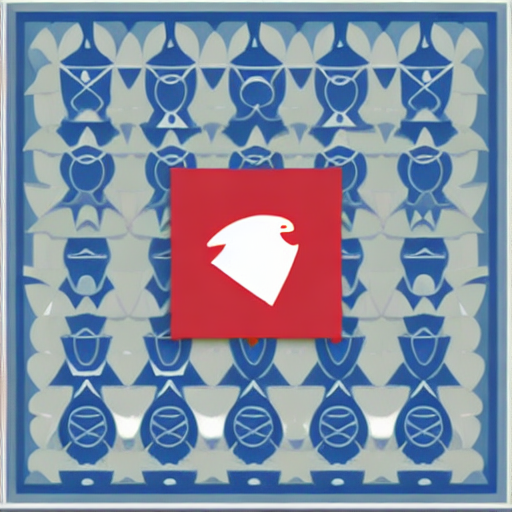

In [15]:
PLAY_CASE_INDEX = 0
PLAY_STEP_INDEX = 12
PLAY_PATCH_FRACTION = 0.35
PLAY_PATCH_MIX = 0.75

play_case = reference.REAL_SD15_CASES[PLAY_CASE_INDEX]
play_initial = prepare_same_seed_sd15_latents(
    pipe, seed=play_case["seed"], device="cuda"
)
play_donor = run_sd15_latent_trajectory(
    pipe, play_case["donor_prompt"], reference.REAL_SD15_NEGATIVE_PROMPT,
    play_initial,
)
play_mask = make_center_mask(
    play_initial.shape[-2], play_initial.shape[-1],
    fraction=PLAY_PATCH_FRACTION, device="cuda",
)
play_patched = run_sd15_latent_trajectory(
    pipe, play_case["recipient_prompt"], reference.REAL_SD15_NEGATIVE_PROMPT,
    play_initial, patch_step_index=PLAY_STEP_INDEX,
    donor_states=play_donor.latent_states, spatial_mask=play_mask,
    patch_mix=PLAY_PATCH_MIX, cache_states=False,
)
display(play_patched.image)


## Anomaly hunting

Find one case where CLIP recovery and regional pixel recovery disagree. Diagnose at least one of these possibilities:

- CLIP recognizes donor semantics even though the target region is visually damaged;
- the donor color appears in the correct region but the text-image margin barely moves;
- a late patch transfers texture while an earlier patch transfers layout;
- the random-latent control changes the score by degrading the recipient rather than adding the donor;
- the wrong-region patch wraps into a semantically relevant part of the image.

Record the image, both metrics, and the counterfactual you would run next. An anomaly is useful only when it narrows the explanation.

## Limitations and Claim Boundary

Supported after the CUDA gate passes: two safe pinned SD1.5 color counterfactuals, exact same-seed DDIM trajectories, one-time latent-region replacement, a complete timestep sweep, CLIP donor-vs-recipient calibration, regional recovery, off-region penalty, and four matched controls.

Not supported: a complete SD1.5 circuit, neuron- or channel-level localization in the real UNet, broad prompt generalization, human perceptual evaluation, SDXL/DiT claims, or the claim that one denoising timestep is universally decisive. The toy channel/layer result and real latent-state result are separate evidence tiers.

## Verification Appendix

The notebook result is primary. `verification_report.json` records the exact
CUDA versions, numeric gates, immutable model revisions, and input hashes used
for release auditing, but it does not substitute for the generated images,
full time sweep, or controls.


In [16]:
def run_smoke_test(cpu=True):
    _ = cpu
    return reference.run_smoke_test(cpu=True)

def run_gpu_test(max_vram_gb: float = 24.0) -> dict:
    return reference.run_gpu_test(max_vram_gb=max_vram_gb)

def run_full_experiment(max_vram_gb: float = 24.0) -> dict:
    return reference.run_full_experiment(max_vram_gb=max_vram_gb)

tests.test_notebook_contract(run_smoke_test)


All tests in `test_notebook_contract` passed!


<details>
<summary>Expected output</summary>

```text
All tests in `test_notebook_contract` passed!
```
</details>

## Reading

- ARENA 1.4.1 activation and path patching: clean/corrupt calibration, visible hooks, heatmaps, and anomaly hunting.
- DDIM: deterministic reverse trajectories make matched causal interventions possible.
- Stable Diffusion 1.5 and Diffusers: the pinned real model and scheduler APIs used here.
- 13.1: attention and prompt-region controls, which this section extends from correlational maps to internal denoising-state intervention.
